# Label-Free FDR Control on CIFAR-10-C with Baseline Comparisons

**Publication-ready evaluation with baseline methods**

This notebook evaluates:
- **FDR Control Methods:** BC-Min (BH), FDR2, Benjamini-Hochberg
- **Baseline Methods:** DOC, ATC, AC, COT (from "Leveraging Unlabeled Data to Predict Out-of-Distribution Performance")
- **Analysis:** MANO vs Accuracy, comparative plots

All figures are publication-ready (300 DPI, PDF + PNG)

## 1. Setup and Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from scipy.stats import spearmanr
import os
from bisect import bisect
from collections import defaultdict
from typing import Dict, Tuple, Optional, List

# Print versions
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Set numpy print options
np.set_printoptions(threshold=np.inf)

# Publication-quality matplotlib settings
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.titlesize': 18,
    'font.family': 'serif',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 10

print(f"Device: {DEVICE}")

# Create output directories
os.makedirs('figures/accuracy', exist_ok=True)
os.makedirs('figures/fdr_curves', exist_ok=True)
os.makedirs('figures/mano', exist_ok=True)
os.makedirs('figures/comparison', exist_ok=True)

print("✓ Setup complete")

NumPy version: 2.0.2
PyTorch version: 2.8.0+cu126
Device: cuda
✓ Setup complete


## 2. Baseline Methods (DOC, ATC, AC, COT)

In [2]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.5 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from scipy.stats import spearmanr
import os
from bisect import bisect
from collections import defaultdict


def negentropy(logits):
    """Compute negentropy (negative entropy)."""
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits).float()
    probs = torch.softmax(logits, dim=1)
    entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=1)
    max_entropy = np.log(logits.shape[1])
    return max_entropy - entropy


def calibration_temp(logits, labels, num_bins=15):
    """Find optimal temperature for calibration."""
    if isinstance(logits, np.ndarray):
        logits = torch.from_numpy(logits).float()
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels).long()
    
    temps = torch.linspace(0.1, 5.0, 50)
    best_temp = 1.0
    best_ece = float('inf')
    
    for temp in temps:
        scaled_probs = torch.softmax(logits / temp, dim=1)
        confidences, predictions = scaled_probs.max(dim=1)
        accuracies = (predictions == labels).float()
        
        bin_boundaries = torch.linspace(0, 1, num_bins + 1)
        ece = 0.0
        
        for i in range(num_bins):
            mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
            if mask.sum() > 0:
                bin_conf = confidences[mask].mean()
                bin_acc = accuracies[mask].mean()
                ece += mask.float().mean() * torch.abs(bin_conf - bin_acc)
        
        if ece < best_ece:
            best_ece = ece
            best_temp = temp.item()
    
    return best_temp


def _to_tensor(x):
    """Convert numpy array or tensor to torch tensor."""
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x).float()
    return x


def predict_ATC_maxconf(source_logits, source_labels, target_logits):
    """Average Threshold Confidence with max confidence."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    source_scores = torch.softmax(source_logits, dim=1).amax(1)
    target_scores = torch.softmax(target_logits, dim=1).amax(1)
    sorted_source_scores, _ = torch.sort(source_scores)
    threshold = sorted_source_scores[-(source_logits.argmax(1) == source_labels).sum()]
    estimate = (target_scores > threshold).float().mean().item()
    return estimate


def predict_ATC_negent(source_logits, source_labels, target_logits):
    """Average Threshold Confidence with negentropy."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    source_scores = negentropy(source_logits)
    target_scores = negentropy(target_logits)
    sorted_source_scores, _ = torch.sort(source_scores)
    threshold = sorted_source_scores[-(source_logits.argmax(1) == source_labels).sum()]
    estimate = (target_scores > threshold).float().mean().item()
    return estimate


def predict_AC(source_logits, source_labels, target_logits):
    """Average Confidence."""
    target_logits = _to_tensor(target_logits)
    return torch.softmax(target_logits, dim=1).amax(1).mean().item()


def predict_DOC(source_logits, source_labels, target_logits):
    """Difference of Confidences."""
    source_logits = _to_tensor(source_logits)
    source_labels = _to_tensor(source_labels).long()
    target_logits = _to_tensor(target_logits)
    
    avg_source_conf = torch.softmax(source_logits, dim=1).amax(1).mean().item()
    avg_target_conf = torch.softmax(target_logits, dim=1).amax(1).mean().item()
    source_acc = (source_logits.argmax(1) == source_labels).float().mean().item()
    return source_acc + (avg_target_conf - avg_source_conf)


try:
    import ot
    
    def predict_COT(source_logits, source_labels, target_logits):
        """Confidence Optimal Transport."""
        source_logits = _to_tensor(source_logits)
        source_labels = _to_tensor(source_labels).long()
        target_logits = _to_tensor(target_logits)
        
        num_classes = source_logits.shape[1]
        source_label_dist = torch.nn.functional.one_hot(source_labels, num_classes).float().mean(0)
        target_probs = torch.softmax(target_logits, dim=1)
        
        cost_matrix = torch.stack([
            (target_probs - onehot).abs().sum(1)
            for onehot in torch.eye(num_classes, device=target_logits.device)
        ], dim=1) / 2
        
        # IMPORTANT: ot.emd() requires all arrays to be numpy
        uniform_dist = np.ones(len(target_probs)) / len(target_probs)
        source_dist = source_label_dist.cpu().numpy()
        cost_matrix_np = cost_matrix.cpu().numpy()
        
        ot_plan = ot.emd(uniform_dist, source_dist, cost_matrix_np)
        ot_cost = np.sum(ot_plan * cost_matrix_np)
        
        s_conf = torch.softmax(source_logits, dim=1).amax(1).mean().item()
        s_acc = (source_logits.argmax(1) == source_labels).float().mean().item()
        conf_gap = s_conf - s_acc
        err_est = ot_cost + conf_gap
        return 1. - err_est
    
    COT_AVAILABLE = True
    print("✓ COT available")
except ImportError:
    COT_AVAILABLE = False
    print("⚠ COT unavailable (install: pip install POT)")


BASELINE_METHODS = {
    'ATC': predict_ATC_maxconf,
    'ATC-NE': predict_ATC_negent,
    'AC': predict_AC,
    'DOC': predict_DOC,
}

if COT_AVAILABLE:
    BASELINE_METHODS['COT'] = predict_COT

print(f"✓ Baseline methods: {list(BASELINE_METHODS.keys())}")

2026-04-21 12:31:14.028067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776774674.384896      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776774674.532490      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776774675.540620      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776774675.540683      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776774675.540686      22 computation_placer.cc:177] computation placer alr

✓ COT available
✓ Baseline methods: ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']


## 3. Model Architecture (WideResNet)

In [4]:
# WideResNet implementation
class WideBasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, dropout_rate=0.3):
        super(WideBasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, padding=1, bias=False)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
            )

    def forward(self, x):
        out = self.dropout(self.conv1(F.relu(self.bn1(x))))
        out = self.conv2(F.relu(self.bn2(out)))
        out += self.shortcut(x)
        return out


class WideResNet(nn.Module):
    def __init__(self, depth=28, widen_factor=10, dropout_rate=0.3, num_classes=10):
        super(WideResNet, self).__init__()
        self.in_planes = 16
        assert ((depth - 4) % 6 == 0), 'Wide-resnet depth should be 6n+4'
        n = (depth - 4) // 6
        k = widen_factor
        nStages = [16, 16*k, 32*k, 64*k]
        
        self.conv1 = nn.Conv2d(3, nStages[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.layer1 = self._wide_layer(WideBasicBlock, nStages[1], n, dropout_rate, stride=1)
        self.layer2 = self._wide_layer(WideBasicBlock, nStages[2], n, dropout_rate, stride=2)
        self.layer3 = self._wide_layer(WideBasicBlock, nStages[3], n, dropout_rate, stride=2)
        self.bn1 = nn.BatchNorm2d(nStages[3], momentum=0.9)
        self.linear1 = nn.Linear(nStages[3], nStages[3])
        self.linear2 = nn.Linear(nStages[3], num_classes)
        self.feature_dim = nStages[3]
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def _wide_layer(self, block, planes, num_blocks, dropout_rate, stride):
        strides = [stride] + [1]*(int(num_blocks)-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, dropout_rate))
            self.in_planes = planes
        return nn.Sequential(*layers)
    
    def get_features(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        return out

    def forward(self, x):
        out = self.get_features(x)
        out = self.linear2(F.relu(self.linear1(out)))
        return out

## 4. Normalizing Flows (SeparateClassFlows)

**TODO:** Add your SeparateClassFlows implementation here

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm


# ─────────────────────────────────────────────────────────────────────────────
# Building blocks
# ─────────────────────────────────────────────────────────────────────────────

class RobustFeatureNormalizer(nn.Module):
    """
    Робастная нормализация признаков для OOD тест-данных.
    
    Алгоритм:
      1. Накапливает median и IQR на train (устойчиво к выбросам)
      2. Нормализует: x_norm = clip((x - median) / IQR, -clip_val, clip_val)
      3. После clip — tanh сжимает всё в (-1, 1) без потери информации
    
    Всё сохраняется в state_dict как буферы.
    """
    def __init__(self, feature_dim, clip_val=5.0, momentum=0.01, eps=1e-6):
        super().__init__()
        self.feature_dim = feature_dim
        self.clip_val    = clip_val
        self.momentum    = momentum
        self.eps         = eps

        # Робастные статистики (median + IQR вместо mean + std)
        self.register_buffer('running_median', torch.zeros(feature_dim))
        self.register_buffer('running_iqr',    torch.ones(feature_dim))
        self.register_buffer('initialized',    torch.tensor(False))

    @torch.no_grad()
    def _update_stats(self, x):
        """Обновляем running median и IQR через EMA."""
        batch_median = x.median(dim=0).values

        q75 = torch.quantile(x, 0.75, dim=0)
        q25 = torch.quantile(x, 0.25, dim=0)
        batch_iqr = (q75 - q25).clamp(min=self.eps)

        if not self.initialized:
            self.running_median.copy_(batch_median)
            self.running_iqr.copy_(batch_iqr)
            self.initialized.fill_(True)
        else:
            self.running_median.mul_(1 - self.momentum).add_(
                batch_median * self.momentum)
            self.running_iqr.mul_(1 - self.momentum).add_(
                batch_iqr * self.momentum)

    def forward(self, x):
        if self.training:
            self._update_stats(x)

        if not self.initialized:
            # Если статистика ещё не собрана — просто tanh
            return torch.tanh(x * 0.01)

        # 1. Центрируем и масштабируем по IQR
        x_norm = (x - self.running_median) / (self.running_iqr + self.eps)

        # 2. Clip жёсткий — убивает совсем дикие выбросы
        x_norm = x_norm.clamp(-self.clip_val, self.clip_val)

        # 3. Tanh — мягкое сжатие в (-1, 1), сохраняет градиенты
        x_norm = torch.tanh(x_norm / self.clip_val)

        return x_norm


class ActNorm(nn.Module):
    """
    Activation normalization — data-driven per-channel scale+bias.
    Initialized from the first FORWARD batch so output has mean=0, std=1.
    `initialized` is registered as a buffer so it is saved/loaded with state_dict.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim       = dim
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias      = nn.Parameter(torch.zeros(dim))
        self.register_buffer('initialized', torch.tensor(False))

    def forward(self, x, reverse=False):
        if not self.initialized and not reverse:
            with torch.no_grad():
                self.bias.data      = -x.mean(0)
                self.log_scale.data = -x.std(0).clamp(min=1e-6).log()
            self.initialized.fill_(True)

        if not reverse:
            y       = (x + self.bias) * self.log_scale.exp()
            log_det = self.log_scale.sum().expand(x.size(0))
            return y, log_det
        else:
            x_rec   = x * (-self.log_scale).exp() - self.bias
            log_det = -self.log_scale.sum().expand(x.size(0))
            return x_rec, log_det


class CouplingLayer(nn.Module):
    """
    Affine coupling layer operating on the full score vector.
    Conditioned on encoded CNN features.

    Split  : x1 = x[:d],  x2 = x[d:]
    Forward: z2 = x2 * exp(s(x1, feat)) + t(x1, feat)
    Reverse: x2 = (z2 - t) * exp(-s)

    Scale head uses Tanh so s ∈ (-1, 1) — prevents exp blow-up.
    """
    def __init__(self, dim, feature_dim, hidden_dim=256, mask_type='first_half'):
        super().__init__()
        self.dim       = dim
        self.mask_type = mask_type

        if mask_type == 'first_half':
            self.d_in  = dim // 2
            self.d_out = dim - dim // 2
        else:
            self.d_in  = dim - dim // 2
            self.d_out = dim // 2

        net_in = self.d_in + feature_dim

        self.net = nn.Sequential(
            nn.Linear(net_in, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
        )
        self.scale_head = nn.Sequential(
            nn.Linear(hidden_dim // 2, self.d_out),
            nn.Tanh(),
        )
        self.translate_head = nn.Linear(hidden_dim // 2, self.d_out)

        # Initialize to identity transform
        nn.init.zeros_(self.scale_head[0].weight)
        nn.init.zeros_(self.scale_head[0].bias)
        nn.init.zeros_(self.translate_head.weight)
        nn.init.zeros_(self.translate_head.bias)

    def _split(self, x):
        if self.mask_type == 'first_half':
            return x[:, :self.d_in], x[:, self.d_in:]
        else:
            return x[:, self.d_out:], x[:, :self.d_out]

    def _merge(self, x1, x2):
        if self.mask_type == 'first_half':
            return torch.cat([x1, x2], dim=1)
        else:
            return torch.cat([x2, x1], dim=1)

    def forward(self, x, features, reverse=False):
        x1, x2     = self._split(x)
        cond_input = torch.cat([x1, features], dim=1)
        h          = self.net(cond_input)
        s          = self.scale_head(h)
        t          = self.translate_head(h)

        if not reverse:
            z2      = x2 * torch.exp(s) + t
            log_det = s.sum(dim=1)
            return self._merge(x1, z2), log_det
        else:
            x2_rec  = (x2 - t) * torch.exp(-s)
            log_det = -s.sum(dim=1)
            return self._merge(x1, x2_rec), log_det


# ─────────────────────────────────────────────────────────────────────────────
# Main flow
# ─────────────────────────────────────────────────────────────────────────────

class ScoreShiftFlow(nn.Module):
    """
    Single normalizing flow that models P(decoy_score_vector | features).

    Architecture:
      - RobustFeatureNormalizer: median/IQR + clamp + tanh → always ∈ (-1, 1)
      - Feature encoder: feature_dim → encoder_dim
      - n_flows CouplingLayers with alternating masks
      - ActNorm between every pair of coupling layers
    """
    def __init__(self,
                 score_dim   = 10,
                 feature_dim = 640,
                 n_flows     = 12,
                 hidden_dim  = 256,
                 encoder_dim = 128,
                 clip_val    = 5.0):
        super().__init__()
        self.score_dim   = score_dim
        self.feature_dim = feature_dim
        self.n_flows     = n_flows
        self._log_2pi    = float(np.log(2 * np.pi))

        # ── Робастная нормализация признаков ─────────────────────────────
        # Любые OOD значения → выход всегда ∈ (-1, 1)
        self.feature_norm = RobustFeatureNormalizer(
            feature_dim, clip_val=clip_val, momentum=0.01)

        # Feature encoder
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, encoder_dim),
            nn.LayerNorm(encoder_dim),
            nn.GELU(),
        )

        # Alternating coupling layers + actnorm
        self.layers = nn.ModuleList()
        for i in range(n_flows):
            mask = 'first_half' if i % 2 == 0 else 'second_half'
            self.layers.append(
                CouplingLayer(score_dim, encoder_dim, hidden_dim, mask)
            )
            if i < n_flows - 1:
                self.layers.append(ActNorm(score_dim))

    def encode(self, features):
        # Нормализуем → всегда ∈ (-1, 1) даже при OOD в миллион раз
        features_norm = self.feature_norm(features)
        return self.feature_encoder(features_norm)

    def forward(self, scores, features, reverse=False):
        """
        reverse=False : scores → latent z,  returns (z, log_det)
        reverse=True  : latent z → scores,  returns (scores, log_det)
        """
        enc         = self.encode(features)
        log_det_sum = torch.zeros(scores.size(0), device=scores.device)

        if not reverse:
            x = scores
            for layer in self.layers:
                if isinstance(layer, ActNorm):
                    x, ld = layer(x, reverse=False)
                else:
                    x, ld = layer(x, enc, reverse=False)
                log_det_sum = log_det_sum + ld
            return x, log_det_sum

        else:
            z = scores
            for layer in reversed(self.layers):
                if isinstance(layer, ActNorm):
                    z, ld = layer(z, reverse=True)
                else:
                    z, ld = layer(z, enc, reverse=True)
                log_det_sum = log_det_sum + ld
            return z, log_det_sum

    def log_prob(self, scores, features):
        """log P(scores | features) under the learned null distribution."""
        z, log_det = self.forward(scores, features, reverse=False)
        log_pz     = -0.5 * (z ** 2).sum(dim=1) \
                     - 0.5 * self.score_dim * self._log_2pi
        return log_pz + log_det

    def sample(self, features):
        """Sample one null score vector per row of features."""
        z = torch.randn(features.size(0), self.score_dim, device=features.device)
        scores, _ = self.forward(z, features, reverse=True)
        return scores


# ─────────────────────────────────────────────────────────────────────────────
# Wrapper
# ─────────────────────────────────────────────────────────────────────────────

class ScoreShiftFlowWrapper(nn.Module):
    """
    Wraps ScoreShiftFlow with train / generate_decoys helpers.
    """
    def __init__(self,
                 num_classes = 10,
                 n_flows     = 12,
                 feature_dim = 640,
                 hidden_dim  = 256,
                 encoder_dim = 128,
                 clip_val    = 5.0):
        super().__init__()
        self.num_classes = num_classes
        self.flow = ScoreShiftFlow(
            score_dim   = num_classes,
            feature_dim = feature_dim,
            n_flows     = n_flows,
            hidden_dim  = hidden_dim,
            encoder_dim = encoder_dim,
            clip_val    = clip_val,
        )
        print("✓ ScoreShiftFlow defined — single flow over full score vector")
        print(f"  clip_val={clip_val}  (OOD robust feature normalization)")

    # ── Training ──────────────────────────────────────────────────────────────

    def train_flow(self,
                   score_dataset,
                   epochs     = 30,
                   lr         = 3e-4,
                   batch_size = 256,
                   device     = 'cuda',
                   patience   = 5,
                   grad_clip  = 1.0):
        self.flow.to(device)
        self.flow.train()   # RobustFeatureNormalizer накапливает статистику

        loader    = DataLoader(score_dataset, batch_size=batch_size,
                               shuffle=True, num_workers=0, pin_memory=True)
        optimizer = torch.optim.AdamW(self.flow.parameters(), lr=lr,
                                      weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01)

        best_loss  = float('inf')
        best_state = None
        no_improve = 0

        for epoch in range(epochs):
            total_loss = 0.0
            n_batches  = 0

            for cnn_scores, features, target_decoy, labels in loader:
                features     = features.to(device)
                target_decoy = target_decoy.to(device)

                log_prob = self.flow.log_prob(target_decoy, features)
                loss     = -log_prob.mean()

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.flow.parameters(), grad_clip)
                optimizer.step()

                total_loss += loss.item()
                n_batches  += 1

            scheduler.step()
            avg_loss = total_loss / max(n_batches, 1)

            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs}  "
                      f"loss={avg_loss:.4f}  "
                      f"lr={scheduler.get_last_lr()[0]:.2e}")

            if avg_loss < best_loss - 1e-4:
                best_loss  = avg_loss
                no_improve = 0
                best_state = {k: v.clone()
                              for k, v in self.flow.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    self.flow.load_state_dict(best_state)
                    break

        if best_state is not None:
            self.flow.load_state_dict(best_state)
        print(f"  ✓ Training complete. Best loss: {best_loss:.4f}")
        return self

    # ── Inference ─────────────────────────────────────────────────────────────

    def generate_decoys(self, score_dataset, device='cuda', n_samples=1):
        """
        Returns:
          model_scores  : (N, C)  original CNN scores
          decoy_scores  : (N, C)  sampled null score vectors
          labels        : (N,)    true labels
        """
        self.flow.to(device)
        self.flow.eval()   # RobustFeatureNormalizer использует frozen статистику

        cnn_list   = []
        decoy_list = []
        lbl_list   = []

        loader = DataLoader(score_dataset, batch_size=256,
                            shuffle=False, num_workers=0)

        with torch.no_grad():
            for cnn_scores, features, target_decoy, labels in loader:
                features = features.to(device)

                if n_samples == 1:
                    decoy = self.flow.sample(features)
                else:
                    samples = torch.stack(
                        [self.flow.sample(features) for _ in range(n_samples)],
                        dim=0)
                    decoy = samples.mean(dim=0)

                cnn_list.append(cnn_scores.cpu().numpy())
                decoy_list.append(decoy.cpu().numpy())
                lbl_list.append(labels.cpu().numpy())

        return (np.concatenate(cnn_list,   axis=0),
                np.concatenate(decoy_list, axis=0),
                np.concatenate(lbl_list,   axis=0))

    # ── OOD диагностика ───────────────────────────────────────────────────────

    def diagnose_feature_ood(self, score_dataset, device='cuda', tile_name=''):
        """
        Показывает насколько фичи тайла OOD относительно train статистики.
        Вызывать после train_flow (когда статистика уже собрана).
        """
        self.flow.to(device)
        self.flow.eval()

        norm = self.flow.feature_norm
        if not norm.initialized:
            print("  ⚠ Normalizer not initialized — train first")
            return

        loader = DataLoader(score_dataset, batch_size=256, shuffle=False)
        all_features = []
        with torch.no_grad():
            for _, features, _, _ in loader:
                all_features.append(features.to(device))
        features = torch.cat(all_features, dim=0)

        # Отклонение от train median в единицах IQR
        deviation = ((features - norm.running_median) /
                     (norm.running_iqr + 1e-6)).abs()

        print(f"  OOD диагностика [{tile_name}]:")
        print(f"    median deviation (IQR units) : {deviation.median():.2f}")
        print(f"    95th pct deviation            : {deviation.quantile(0.95):.2f}")
        print(f"    max deviation                 : {deviation.max():.2f}")
        print(f"    % features с deviation >  5  : "
              f"{(deviation > 5).float().mean() * 100:.1f}%")
        print(f"    % features с deviation > 10  : "
              f"{(deviation > 10).float().mean() * 100:.1f}%")
        print(f"    % features с deviation > 100 : "
              f"{(deviation > 100).float().mean() * 100:.1f}%")

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from scipy.stats import spearmanr, ks_2samp
import os
from bisect import bisect
from collections import defaultdict
from typing import Dict, Tuple, Optional, List

print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

np.set_printoptions(threshold=np.inf)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'figure.titlesize': 18,
    'font.family': 'serif',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 10
print(f"Device: {DEVICE}")

os.makedirs('figures/accuracy',      exist_ok=True)
os.makedirs('figures/diagnostics',   exist_ok=True)
os.makedirs('figures/comparison',    exist_ok=True)
os.makedirs('figures/distributions', exist_ok=True)

# ============================================================
# CONFIG
# ============================================================
MODEL_PATH   = '/kaggle/input/models/arinaromashkina/wide-res-net-1/pytorch/default/1/best_model.pth'
CIFAR_C_PATH = '/kaggle/input/datasets/arinaromashkina/cifar-10-c/CIFAR-10-C'
FLOWS_PATH   = 'cond_flows_model_cifar10_big_new.pth'
NUM_CLASSES  = 10
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
SEVERITIES   = [1, 2, 3, 4, 5]
MIN_POOL     = 30

# Стратегия формирования target для decoy при обучении Flow:
# 'score_coord'  — заменяем только координату pred_class на отрицат. скор из пула
# 'full_vector'  — заменяем весь вектор скоров на вектор другого (неправильного) примера
# 'pool_replace' — как score_coord, но с полным вектором из пула (текущий вариант)
DECOY_STRATEGY = 'score_coord'  # выбери: 'score_coord', 'full_vector', 'pool_replace'

CORRUPTIONS_TO_TEST = [
    'gaussian_noise',           # Гауссов шум
    'shot_noise',               # Дробовой шум
    'impulse_noise',            # Импульсный шум
    'defocus_blur',             # Дефокусировка
    'glass_blur',               # Стеклянное размытие
    'motion_blur',              # Размытие движения
    'zoom_blur',                # Размытие при зуме
    'snow',                     # Снег
    'frost',                    # Иней
    'fog',                      # Туман
    'brightness',               # Яркость
    'contrast',                 # Контраст
    'elastic_transform',        # Эластичная трансформация
    'pixelate',                 # Пикселизация
    'jpeg_compression',         # JPEG-сжатие
    'speckle_noise',            # Спекл-шум
    'gaussian_blur',            # Гауссово размытие
    'spatter',                  # Брызги
    'saturate'                  # Насыщенность
]


cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std  = [0.2470, 0.2435, 0.2616]

print(f"Device: {DEVICE}")
print(f"Decoy strategy: {DECOY_STRATEGY}")

# ============================================================
# TRANSFORMS & DATA LOADING
# ============================================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

def cifar_c_transform(img: np.ndarray) -> torch.Tensor:
    img = torch.from_numpy(img).float() / 255.0
    img = img.permute(2, 0, 1)
    return transforms.Normalize(cifar_mean, cifar_std)(img)

print("Loading CIFAR-10...")
cifar_train = datasets.CIFAR10('./data', train=True,  download=True,
                                transform=transform_train)
cifar_test  = datasets.CIFAR10('./data', train=False, download=True,
                                transform=transform_test)
print(f"✓ train={len(cifar_train)}, test={len(cifar_test)}")

# ============================================================
# CIFAR-10-C DATASET
# ============================================================
class CIFAR10CDataset:
    """Single severity slice of CIFAR-10-C."""
    def __init__(self, data_path, corruption_type, severity, transform=None):
        all_images = np.load(f"{data_path}/{corruption_type}.npy")
        all_labels = np.load(f"{data_path}/labels.npy")
        s, e = (severity - 1) * 10_000, severity * 10_000
        self.images    = all_images[s:e]
        self.labels    = all_labels[s:e].astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


class CIFAR10CAllSeverities:
    """All 5 severity slices concatenated for one corruption."""
    def __init__(self, data_path, corruption_type, transform=None):
        all_images = np.load(f"{data_path}/{corruption_type}.npy")
        all_labels = np.load(f"{data_path}/labels.npy").astype(np.int64)
        self.images    = all_images
        self.labels    = all_labels
        self.transform = transform
        self.severity_datasets = {
            sev: CIFAR10CDataset(data_path, corruption_type, sev, transform)
            for sev in SEVERITIES
        }

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


print("Loading CIFAR-10-C datasets...")
test_corrupted_datasets: dict = {}
for corruption in CORRUPTIONS_TO_TEST:
    try:
        test_corrupted_datasets[corruption] = CIFAR10CAllSeverities(
            CIFAR_C_PATH, corruption, transform=cifar_c_transform)
        print(f"  ✓ {corruption}  ({len(test_corrupted_datasets[corruption])} samples)")
    except Exception as exc:
        print(f"  ✗ {corruption}: {exc}")
print(f"✓ Loaded {len(test_corrupted_datasets)} corrupted datasets")

# ============================================================
# MODEL  (WideResNet must be defined before this cell)
# ============================================================
print("\nLoading WideResNet...")
cifar_model = WideResNet(depth=28, widen_factor=10,
                          dropout_rate=0.3, num_classes=NUM_CLASSES)
cifar_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
cifar_model = cifar_model.to(DEVICE)
cifar_model.eval()
print("✓ Model ready")

# ============================================================
# SCORE FEATURE DATASET
# ============================================================
class ScoreFeatureDataset(torch.utils.data.Dataset):
    """
    Хранит:
      cnn_scores          — логиты модели  [N, C]
      features            — признаки penultimate layer  [N, D]
      target_decoy_scores — decoy-векторы для обучения Flow  [N, C]
      labels              — истинные метки  [N]
    """
    def __init__(self, cnn_scores, features, target_decoy_scores, labels):
        self.cnn_scores          = cnn_scores
        self.features            = features
        self.target_decoy_scores = target_decoy_scores
        self.labels              = labels

    def __len__(self):
        return len(self.cnn_scores)

    def __getitem__(self, idx):
        return (self.cnn_scores[idx], self.features[idx],
                self.target_decoy_scores[idx], self.labels[idx])

# ============================================================
# COLLECT TRAIN SCORES
# ============================================================
def collect_train_scores(model, train_dataset,
                          num_classes: int = 10,
                          device: str = 'cuda') -> tuple:
    """Returns (train_scores [N×C], train_labels [N])."""
    model.eval()
    loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
    sc_list, lb_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Collecting train scores'):
            images = images.to(device)
            feats  = model.get_features(images)
            scores = model.linear2(F.relu(model.linear1(feats)))
            sc_list.append(scores.cpu().numpy())
            lb_list.append(labels.numpy())
    return np.concatenate(sc_list), np.concatenate(lb_list)

# ============================================================
# DECOY POOLS
#
# Теория Mix-Max (π_mm = 0):
#   H₀(t) = "предсказанный класс ĉ неверный"
#   Decoy Z(t) должен симулировать P(score_ĉ | argmax=ĉ, label≠ĉ)
#   Т.е. score_c на примерах, где модель предсказала c, но ошиблась.
#   Тогда выполняется exchangeability: f(t)|wrong ~ Z(t)
# ============================================================

def build_error_conditioned_pools(train_scores: np.ndarray,
                                   train_labels: np.ndarray,
                                   num_classes:  int,
                                   verbose:      bool = True) -> dict:
    """
    Строит два типа пулов для двух стратегий decoy:

    pool_score[c] = score_c на примерах где argmax=c И label≠c
                    (для стратегий 'score_coord' и 'pool_replace')

    pool_vectors[c] = полные score-векторы примеров где label≠c
                      (для стратегии 'full_vector')

    Если ошибок < MIN_POOL — fallback на label≠c (только для pool_score).

    Логика Mix-Max (π_mm = 0):
      f(t) = model_scores[i, ĉ_i]   — target score
      Z(t) ~ pool_score[ĉ_i]        — decoy score
      Под H₀ (ошибка): f(t) и Z(t) должны быть exchangeable.
    """
    pred_classes = train_scores.argmax(axis=1)
    pool_score   = {}
    pool_vectors = {}

    if verbose:
        acc = (pred_classes == train_labels).mean()
        print(f"\nBuilding error-conditioned decoy pools  "
              f"(train acc={acc:.4f})")

    for c in range(num_classes):
        # ── pool_score: coord c при ошибке ───────────────────────────────
        error_mask = (pred_classes == c) & (train_labels != c)
        n_err      = error_mask.sum()

        if n_err >= MIN_POOL:
            pool_score[c] = train_scores[error_mask, c]
            src = f"per-class errors (argmax=c & label≠c)"
        else:
            neg_mask      = train_labels != c
            pool_score[c] = train_scores[neg_mask, c]
            src = f"fallback (label≠c)"

        # ── pool_vectors: полные векторы при label≠c ─────────────────────
        neg_mask         = train_labels != c
        pool_vectors[c]  = train_scores[neg_mask]   # shape [M, C]

        if verbose:
            p = pool_score[c]
            print(f"  class {c}: n_score={len(p):6d}  "
                  f"n_vec={pool_vectors[c].shape[0]:6d}  "
                  f"[{p.min():.3f}, {p.max():.3f}]  "
                  f"mean={p.mean():.3f}  n_errors={n_err:4d}  src={src}")

    return pool_score, pool_vectors

# Все стратегии симулируют P(score | wrong) для обучения Flow.

def _build_decoy_score_coord(sc_np: np.ndarray,
                              pool_score: dict,
                              rng: np.random.Generator) -> np.ndarray:
    """
    Стратегия A: заменяем только координату pred_class.
    decoy[i, ĉ_i] ~ pool_score[ĉ_i]
    decoy[i, j]   = score[i, j]  для j ≠ ĉ_i
    """
    pred_classes = sc_np.argmax(axis=1)
    dc_np        = sc_np.copy()
    for c in range(sc_np.shape[1]):
        mask = pred_classes == c
        if not mask.any():
            continue
        pool = pool_score[c]
        if len(pool) == 0:
            continue
        dc_np[mask, c] = rng.choice(pool, size=mask.sum(), replace=True)
    return dc_np



def create_score_dataset_with_decoys(
        dataset,
        cnn_model,
        pool_score:   dict,
        pool_vectors: dict,
        strategy:     str  = 'score_coord',
        device:       str  = 'cuda') -> 'ScoreFeatureDataset':
    """
    Создаёт ScoreFeatureDataset с target_decoy для обучения Flow.

    strategy:
      'score_coord'  — заменяем только coord pred_class (Strategy A)
      'full_vector'  — заменяем весь вектор (Strategy B)
      'pool_replace' — как score_coord (Strategy C, legacy)

    target_decoy используется только при ОБУЧЕНИИ Flow.
    При инференсе Flow генерирует decoys сам.
    """
    assert strategy in ('score_coord', 'full_vector', 'pool_replace'), \
        f"Unknown strategy: {strategy}"

    cnn_model.eval()
    loader  = DataLoader(dataset, batch_size=256, shuffle=False)
    sc_list, ft_list, dc_list, lb_list = [], [], [], []
    rng     = np.random.default_rng(0)

    with torch.no_grad():
        for images, labels in tqdm(loader,
                                   desc=f'Score dataset [{strategy}]',
                                   leave=False):
            images = images.to(device)
            feats  = cnn_model.get_features(images)
            scores = cnn_model.linear2(F.relu(cnn_model.linear1(feats)))
            sc     = scores.cpu()
            ft     = feats.cpu()
            sc_np  = sc.numpy()

            if strategy == 'score_coord':
                dc_np = _build_decoy_score_coord(sc_np, pool_score, rng)
            elif strategy == 'full_vector':
                dc_np = _build_decoy_full_vector(sc_np, pool_vectors, rng)
            else:   # 'pool_replace'
                dc_np = _build_decoy_pool_replace(sc_np, pool_score, rng)

            dc = torch.from_numpy(dc_np).float()

            sc_list.append(sc)
            ft_list.append(ft)
            dc_list.append(dc)
            lb_list.append(labels)

    return ScoreFeatureDataset(
        torch.cat(sc_list),
        torch.cat(ft_list),
        torch.cat(dc_list),
        torch.cat(lb_list),
    )


def create_score_dataset_no_decoys(dataset, cnn_model,
                                    device: str = 'cuda') -> 'ScoreFeatureDataset':
    """
    Создаёт ScoreFeatureDataset без замены decoys (placeholder = scores).
    Используется там, где decoys генерируются отдельно (инференс Flow).
    """
    cnn_model.eval()
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    sc_list, ft_list, lb_list = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Score dataset', leave=False):
            images = images.to(device)
            feats  = cnn_model.get_features(images)
            scores = cnn_model.linear2(F.relu(cnn_model.linear1(feats)))
            sc_list.append(scores.cpu())
            ft_list.append(feats.cpu())
            lb_list.append(labels)

    all_scores = torch.cat(sc_list)
    all_feats  = torch.cat(ft_list)
    all_labels = torch.cat(lb_list)

    return ScoreFeatureDataset(
        all_scores, all_feats, all_scores.clone(), all_labels)

print("\n" + "="*70)
print("COLLECTING TRAIN SCORES")
print("="*70)
train_scores_raw, train_labels_raw = collect_train_scores(
    cifar_model, cifar_train, NUM_CLASSES, DEVICE)
print(f"Train scores: {train_scores_raw.shape}  "
      f"acc={(train_scores_raw.argmax(1) == train_labels_raw).mean():.4f}")

print("\n" + "="*70)
print("BUILDING ERROR-CONDITIONED DECOY POOLS")
print("="*70)
pool_score, pool_vectors = build_error_conditioned_pools(
    train_scores_raw, train_labels_raw, NUM_CLASSES, verbose=True)

# ── Логиты train для baselines ────────────────────────────────────────────────
source_logits_np = train_scores_raw
source_labels_np = train_labels_raw

# ============================================================
# FLOW MODEL
# ============================================================
print("\n" + "="*70)
print("FLOW MODEL")
print("="*70)

FEATURE_DIM=640
score_shift_flow = ScoreShiftFlowWrapper(
    num_classes = NUM_CLASSES,
    n_flows     = 12,
    feature_dim = FEATURE_DIM,
    hidden_dim  = 256,
    encoder_dim = 128,
    clip_val    = 5.0,      # ← OOD защита
).to(DEVICE)


# score_shift_flow = ScoreShiftFlowWrapper(
#     num_classes = NUM_CLASSES,
#     n_flows     = 12,
#     feature_dim = 640,
#     hidden_dim  = 256,
#     encoder_dim = 128,
# ).to(DEVICE)

print(f"Creating train score dataset (strategy='{DECOY_STRATEGY}')...")
train_score_dataset = create_score_dataset_with_decoys(
    cifar_train, cifar_model,
    pool_score   = pool_score,
    pool_vectors = pool_vectors,
    strategy     = DECOY_STRATEGY,
    device       = DEVICE,
)

if os.path.exists(FLOWS_PATH):
    score_shift_flow.load_state_dict(
        torch.load(FLOWS_PATH, map_location=DEVICE))
    print(f"✓ Flow loaded from {FLOWS_PATH}")
else:
    print("Training ScoreShiftFlow...")
    score_shift_flow.train_flow(
        train_score_dataset, epochs=30, lr=3e-4,
        batch_size=256, device=DEVICE, patience=5, grad_clip=1.0)
    torch.save(score_shift_flow.state_dict(), FLOWS_PATH)
    print(f"✓ Flow saved to {FLOWS_PATH}")

score_shift_flow.eval()

NumPy version: 2.0.2
PyTorch version: 2.8.0+cu126
Device: cuda
Device: cuda
Decoy strategy: score_coord
Loading CIFAR-10...


100%|██████████| 170M/170M [00:01<00:00, 91.4MB/s]


✓ train=50000, test=10000
Loading CIFAR-10-C datasets...
  ✓ gaussian_noise  (50000 samples)
  ✓ shot_noise  (50000 samples)
  ✓ impulse_noise  (50000 samples)
  ✓ defocus_blur  (50000 samples)
  ✓ glass_blur  (50000 samples)
  ✓ motion_blur  (50000 samples)
  ✓ zoom_blur  (50000 samples)
  ✓ snow  (50000 samples)
  ✓ frost  (50000 samples)
  ✓ fog  (50000 samples)
  ✓ brightness  (50000 samples)
  ✓ contrast  (50000 samples)
  ✓ elastic_transform  (50000 samples)
  ✓ pixelate  (50000 samples)
  ✓ jpeg_compression  (50000 samples)
  ✓ speckle_noise  (50000 samples)
  ✓ gaussian_blur  (50000 samples)
  ✓ spatter  (50000 samples)
  ✓ saturate  (50000 samples)
✓ Loaded 19 corrupted datasets

Loading WideResNet...
✓ Model ready

COLLECTING TRAIN SCORES


Train scores: (50000, 10)  acc=0.9171

BUILDING ERROR-CONDITIONED DECOY POOLS

Building error-conditioned decoy pools  (train acc=0.9171)
  class 0: n_score=   633  n_vec= 45000  [0.566, 4.745]  mean=2.900  n_errors= 633  src=per-class errors (argmax=c & label≠c)
  class 1: n_score=   376  n_vec= 45000  [1.459, 5.462]  mean=3.429  n_errors= 376  src=per-class errors (argmax=c & label≠c)
  class 2: n_score=    88  n_vec= 45000  [1.116, 4.380]  mean=2.499  n_errors=  88  src=per-class errors (argmax=c & label≠c)
  class 3: n_score=  1369  n_vec= 45000  [1.095, 5.598]  mean=2.977  n_errors=1369  src=per-class errors (argmax=c & label≠c)
  class 4: n_score=   219  n_vec= 45000  [1.235, 4.520]  mean=2.717  n_errors= 219  src=per-class errors (argmax=c & label≠c)
  class 5: n_score=   395  n_vec= 45000  [1.080, 4.638]  mean=2.885  n_errors= 395  src=per-class errors (argmax=c & label≠c)
  class 6: n_score=   614  n_vec= 45000  [0.785, 5.057]  mean=2.834  n_errors= 614  src=per-class errors (

Training ScoreShiftFlow...
  Epoch   5/30  loss=-16.8878  lr=2.80e-04
  Epoch  10/30  loss=-19.7447  lr=2.26e-04
  Epoch  15/30  loss=-21.7684  lr=1.51e-04
  Epoch  20/30  loss=-23.3514  lr=7.73e-05
  Epoch  25/30  loss=-24.5132  lr=2.29e-05
  Epoch  30/30  loss=-25.0962  lr=3.00e-06
  ✓ Training complete. Best loss: -25.0962
✓ Flow saved to cond_flows_model_cifar10_big_new.pth


ScoreShiftFlowWrapper(
  (flow): ScoreShiftFlow(
    (feature_norm): RobustFeatureNormalizer()
    (feature_encoder): Sequential(
      (0): Linear(in_features=640, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (5): GELU(approximate='none')
    )
    (layers): ModuleList(
      (0): CouplingLayer(
        (net): Sequential(
          (0): Linear(in_features=133, out_features=256, bias=True)
          (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (2): GELU(approximate='none')
          (3): Linear(in_features=256, out_features=256, bias=True)
          (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (5): GELU(approximate='none')
          (6): Linear(in_features=256, out_features=128, bias=True)
          (7): GELU(approximate='

In [7]:
source_logits, ds_train, source_labels =  ms, ds_flow, ls = score_shift_flow.generate_decoys(
        train_score_dataset, device=DEVICE)


────────────────────────────────────────────────────────────
  CORRUPTION: gaussian_noise
────────────────────────────────────────────────────────────


  ATC: 0.529 (error: 0.093)
────────────────────────────────────────────────────────────
  ATC-NE: 0.514 (error: 0.078)
────────────────────────────────────────────────────────────
  AC: 0.729 (error: 0.293)
────────────────────────────────────────────────────────────
  DOC: 0.710 (error: 0.274)
────────────────────────────────────────────────────────────
  COT: 0.511 (error: 0.075)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


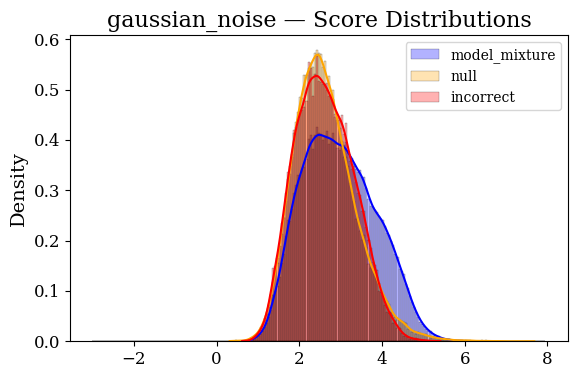

  accuracy : 0.4360
  error/pi0: 0.5640


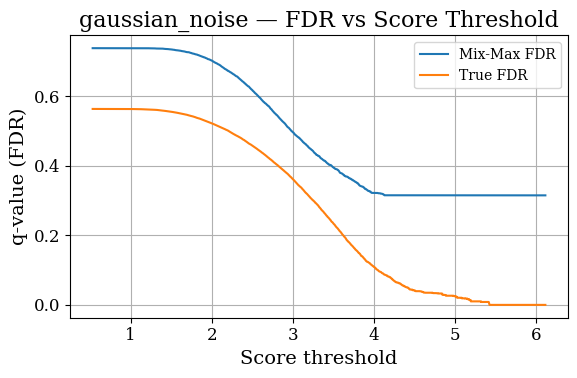

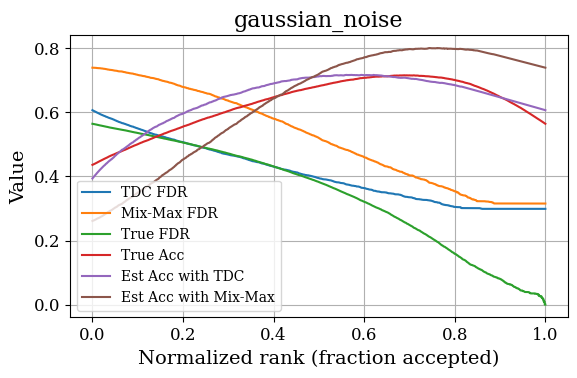


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.4360      0.7153
  TDC  (est | err)             0.3935  +0.0425  0.7166  +0.0013
  Mix-Max (est | err)          0.2611  +0.1749  0.8003  +0.0850

────────────────────────────────────────────────────────────
  CORRUPTION: shot_noise
────────────────────────────────────────────────────────────


  ATC: 0.621 (error: 0.067)
────────────────────────────────────────────────────────────
  ATC-NE: 0.600 (error: 0.047)
────────────────────────────────────────────────────────────
  AC: 0.776 (error: 0.222)
────────────────────────────────────────────────────────────
  DOC: 0.757 (error: 0.203)
────────────────────────────────────────────────────────────
  COT: 0.615 (error: 0.062)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


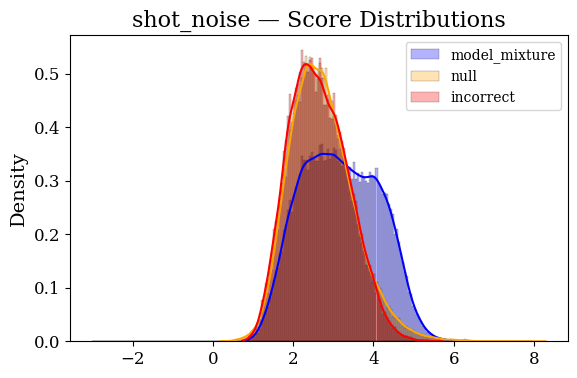

  accuracy : 0.5534
  error/pi0: 0.4466


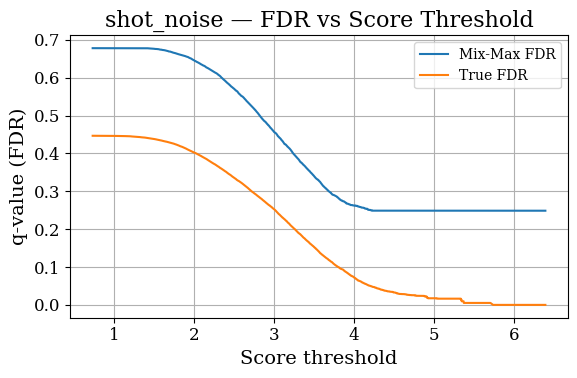

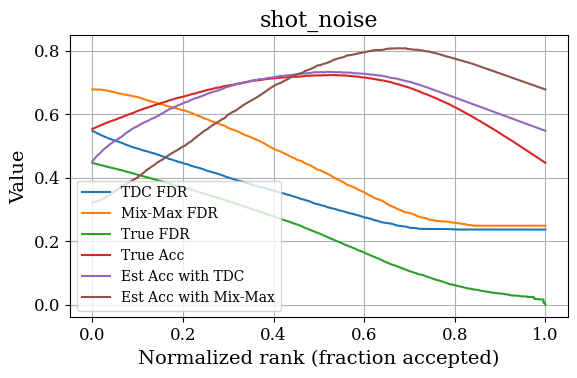


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.5534      0.7233
  TDC  (est | err)             0.4524  +0.1009  0.7335  +0.0102
  Mix-Max (est | err)          0.3220  +0.2313  0.8080  +0.0847

────────────────────────────────────────────────────────────
  CORRUPTION: impulse_noise
────────────────────────────────────────────────────────────


  ATC: 0.546 (error: 0.043)
────────────────────────────────────────────────────────────
  ATC-NE: 0.510 (error: 0.078)
────────────────────────────────────────────────────────────
  AC: 0.731 (error: 0.143)
────────────────────────────────────────────────────────────
  DOC: 0.712 (error: 0.124)
────────────────────────────────────────────────────────────
  COT: 0.656 (error: 0.068)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


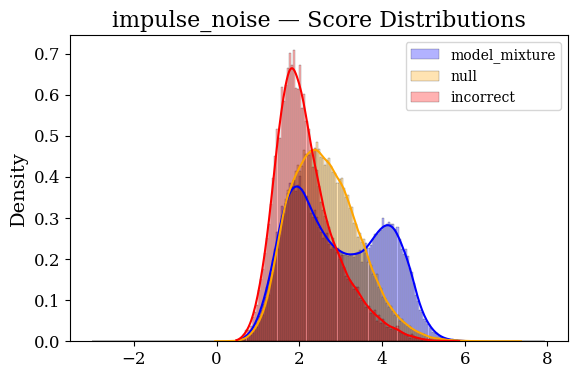

  accuracy : 0.5883
  error/pi0: 0.4117


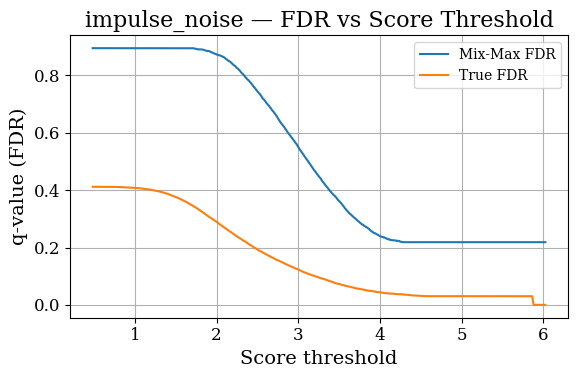

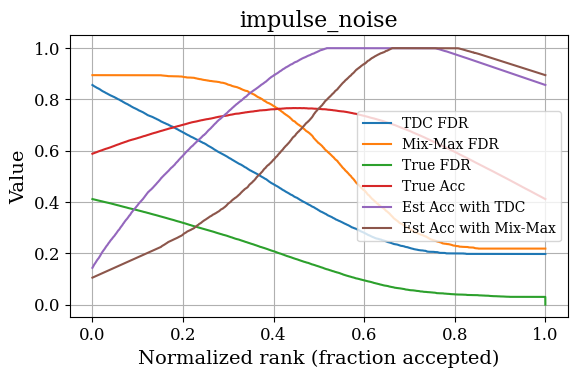


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.5883      0.7666
  TDC  (est | err)             0.1436  +0.4447  1.0000  +0.2334
  Mix-Max (est | err)          0.1053  +0.4831  1.0000  +0.2334

────────────────────────────────────────────────────────────
  CORRUPTION: defocus_blur
────────────────────────────────────────────────────────────


  ATC: 0.763 (error: 0.034)
────────────────────────────────────────────────────────────
  ATC-NE: 0.749 (error: 0.020)
────────────────────────────────────────────────────────────
  AC: 0.852 (error: 0.123)
────────────────────────────────────────────────────────────
  DOC: 0.833 (error: 0.104)
────────────────────────────────────────────────────────────
  COT: 0.780 (error: 0.051)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


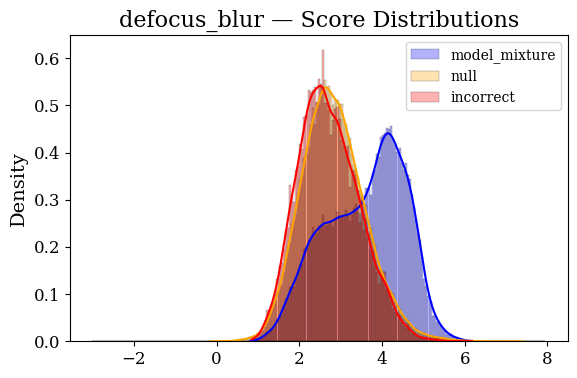

  accuracy : 0.7286
  error/pi0: 0.2714


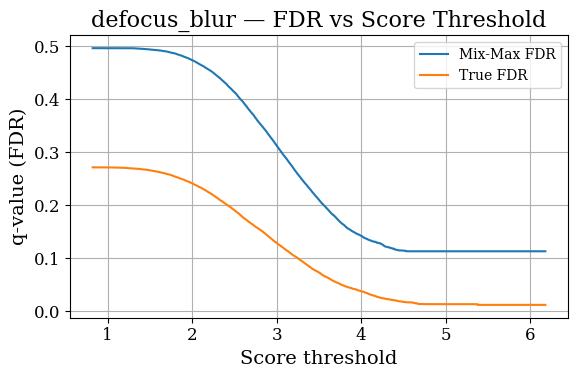

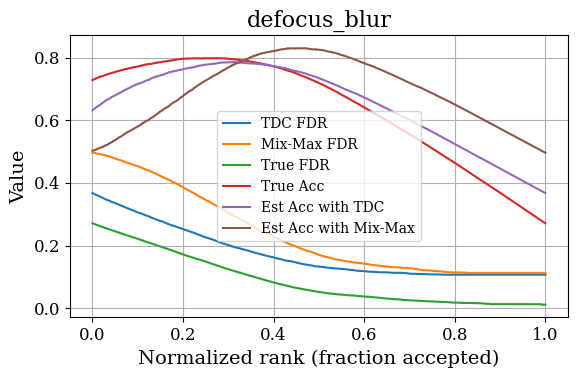


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.7286      0.7986
  TDC  (est | err)             0.6322  +0.0963  0.7864  +0.0122
  Mix-Max (est | err)          0.5035  +0.2251  0.8305  +0.0320

────────────────────────────────────────────────────────────
  CORRUPTION: glass_blur
────────────────────────────────────────────────────────────


  ATC: 0.462 (error: 0.150)
────────────────────────────────────────────────────────────
  ATC-NE: 0.401 (error: 0.089)
────────────────────────────────────────────────────────────
  AC: 0.687 (error: 0.375)
────────────────────────────────────────────────────────────
  DOC: 0.668 (error: 0.356)
────────────────────────────────────────────────────────────
  COT: 0.421 (error: 0.109)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


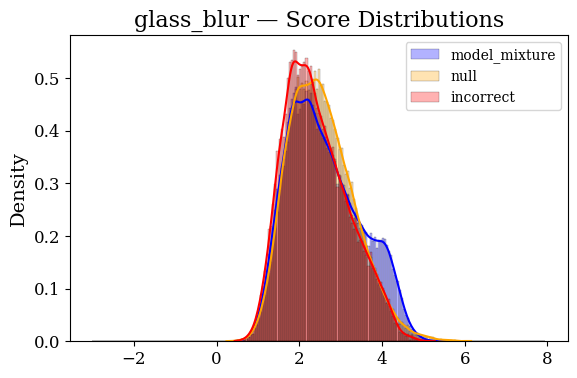

  accuracy : 0.3121
  error/pi0: 0.6879


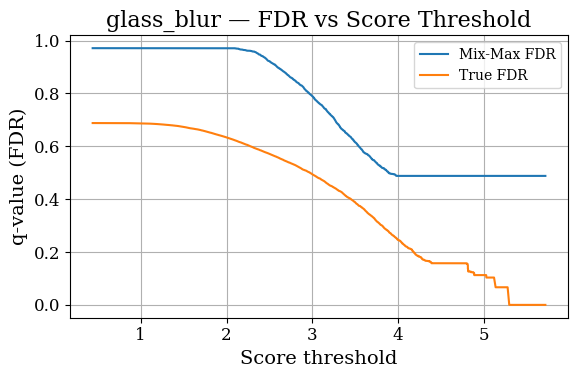

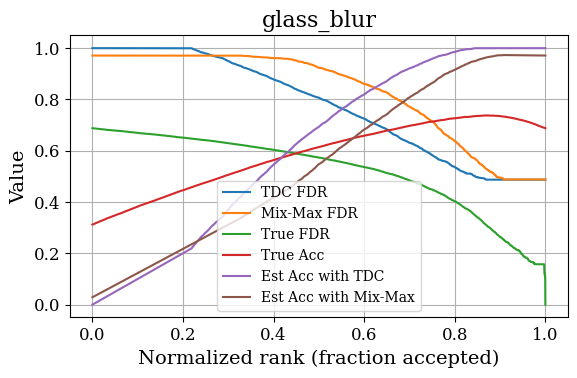


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.3121      0.7376
  TDC  (est | err)             0.0000  +0.3121  1.0000  +0.2624
  Mix-Max (est | err)          0.0288  +0.2833  0.9734  +0.2358

────────────────────────────────────────────────────────────
  CORRUPTION: motion_blur
────────────────────────────────────────────────────────────


  ATC: 0.744 (error: 0.090)
────────────────────────────────────────────────────────────
  ATC-NE: 0.732 (error: 0.078)
────────────────────────────────────────────────────────────
  AC: 0.838 (error: 0.184)
────────────────────────────────────────────────────────────
  DOC: 0.819 (error: 0.165)
────────────────────────────────────────────────────────────
  COT: 0.693 (error: 0.039)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


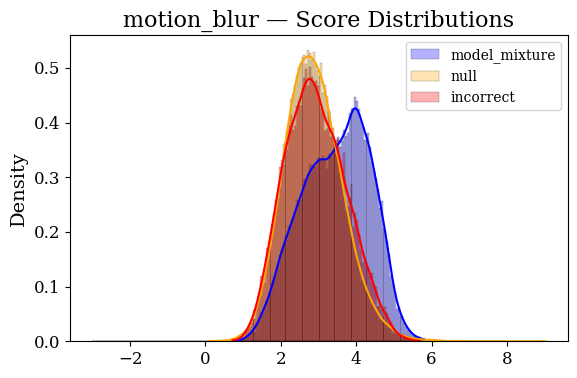

  accuracy : 0.6543
  error/pi0: 0.3457


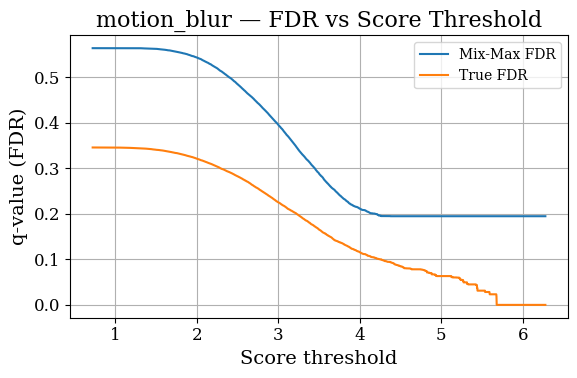

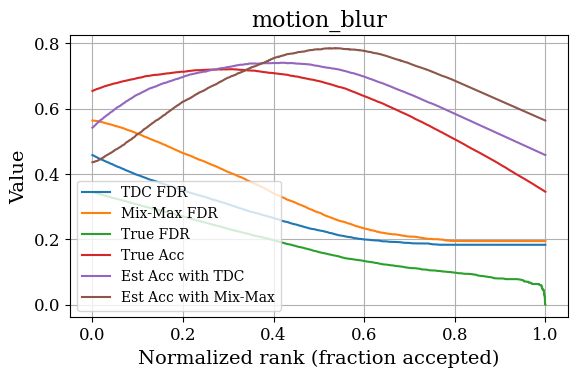


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6543      0.7212
  TDC  (est | err)             0.5420  +0.1123  0.7410  +0.0198
  Mix-Max (est | err)          0.4362  +0.2181  0.7854  +0.0642

────────────────────────────────────────────────────────────
  CORRUPTION: zoom_blur
────────────────────────────────────────────────────────────


  ATC: 0.720 (error: 0.042)
────────────────────────────────────────────────────────────
  ATC-NE: 0.697 (error: 0.019)
────────────────────────────────────────────────────────────
  AC: 0.825 (error: 0.147)
────────────────────────────────────────────────────────────
  DOC: 0.806 (error: 0.128)
────────────────────────────────────────────────────────────
  COT: 0.728 (error: 0.050)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


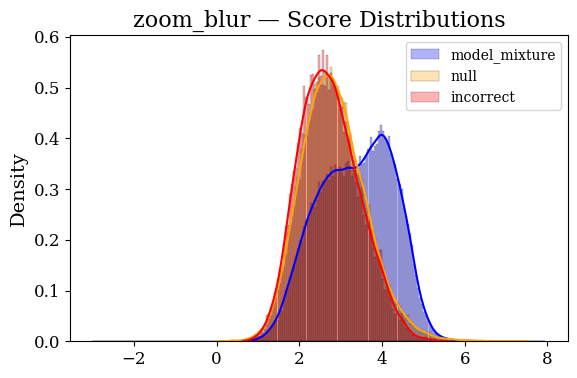

  accuracy : 0.6781
  error/pi0: 0.3219


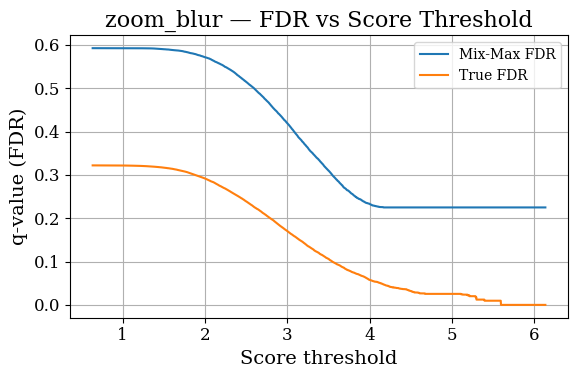

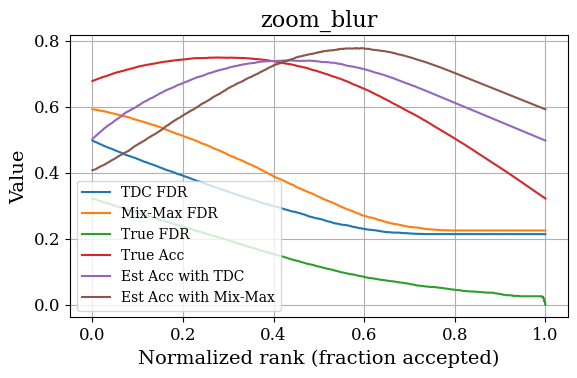


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6781      0.7496
  TDC  (est | err)             0.5023  +0.1758  0.7408  +0.0088
  Mix-Max (est | err)          0.4076  +0.2705  0.7778  +0.0282

────────────────────────────────────────────────────────────
  CORRUPTION: snow
────────────────────────────────────────────────────────────


  ATC: 0.787 (error: 0.059)
────────────────────────────────────────────────────────────
  ATC-NE: 0.771 (error: 0.044)
────────────────────────────────────────────────────────────
  AC: 0.862 (error: 0.135)
────────────────────────────────────────────────────────────
  DOC: 0.843 (error: 0.116)
────────────────────────────────────────────────────────────
  COT: 0.777 (error: 0.050)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


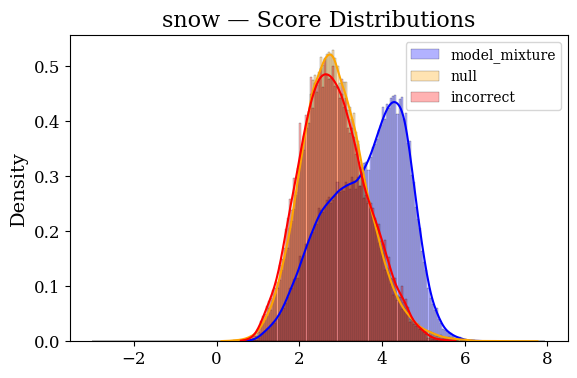

  accuracy : 0.7270
  error/pi0: 0.2730


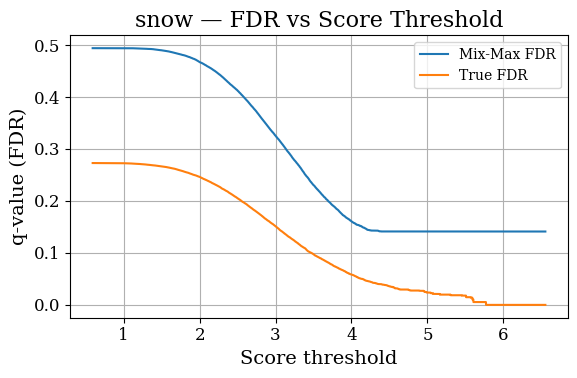

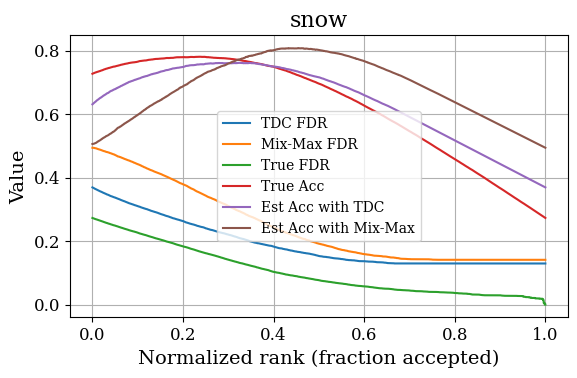


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.7270      0.7807
  TDC  (est | err)             0.6308  +0.0963  0.7615  +0.0192
  Mix-Max (est | err)          0.5060  +0.2211  0.8077  +0.0269

────────────────────────────────────────────────────────────
  CORRUPTION: frost
────────────────────────────────────────────────────────────


  ATC: 0.706 (error: 0.026)
────────────────────────────────────────────────────────────
  ATC-NE: 0.678 (error: 0.002)
────────────────────────────────────────────────────────────
  AC: 0.819 (error: 0.139)
────────────────────────────────────────────────────────────
  DOC: 0.800 (error: 0.120)
────────────────────────────────────────────────────────────
  COT: 0.725 (error: 0.045)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


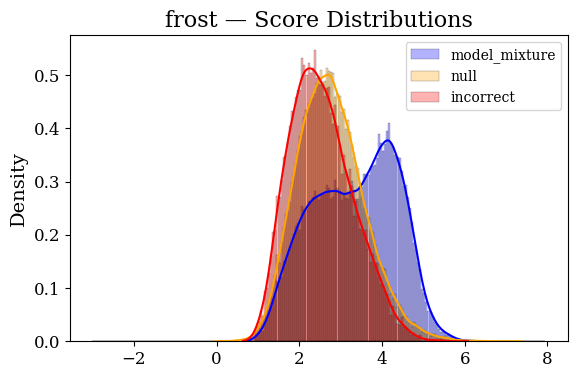

  accuracy : 0.6801
  error/pi0: 0.3199


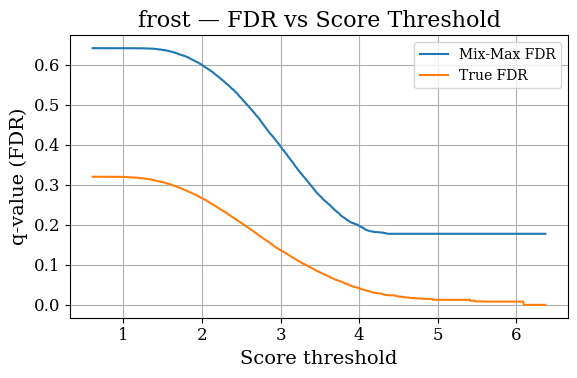

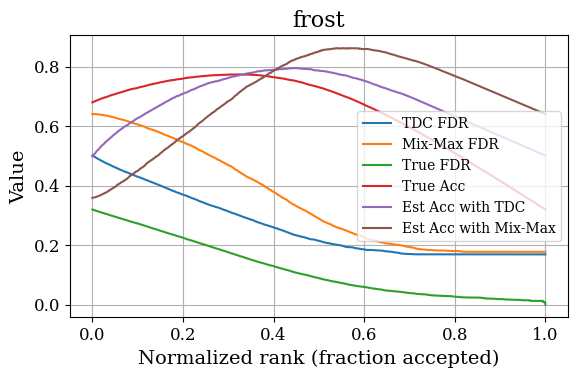


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6801      0.7742
  TDC  (est | err)             0.4987  +0.1814  0.7958  +0.0216
  Mix-Max (est | err)          0.3591  +0.3210  0.8624  +0.0881

────────────────────────────────────────────────────────────
  CORRUPTION: fog
────────────────────────────────────────────────────────────


  ATC: 0.862 (error: 0.048)
────────────────────────────────────────────────────────────
  ATC-NE: 0.857 (error: 0.042)
────────────────────────────────────────────────────────────
  AC: 0.904 (error: 0.090)
────────────────────────────────────────────────────────────
  DOC: 0.885 (error: 0.071)
────────────────────────────────────────────────────────────
  COT: 0.823 (error: 0.008)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


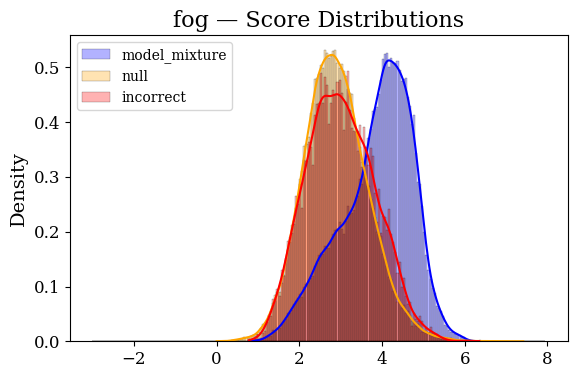

  accuracy : 0.8143
  error/pi0: 0.1857


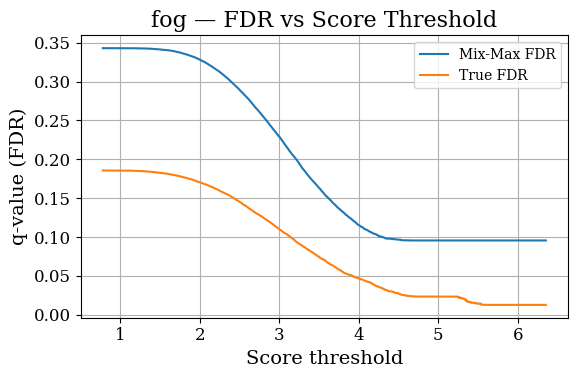

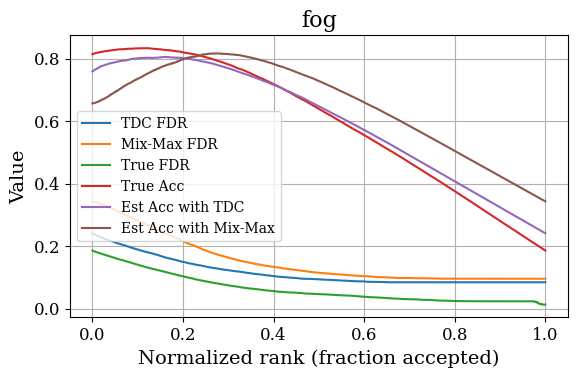


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.8143      0.8335
  TDC  (est | err)             0.7590  +0.0554  0.8055  +0.0280
  Mix-Max (est | err)          0.6569  +0.1574  0.8168  +0.0167

────────────────────────────────────────────────────────────
  CORRUPTION: brightness
────────────────────────────────────────────────────────────


  ATC: 0.901 (error: 0.010)
────────────────────────────────────────────────────────────
  ATC-NE: 0.903 (error: 0.012)
────────────────────────────────────────────────────────────
  AC: 0.929 (error: 0.038)
────────────────────────────────────────────────────────────
  DOC: 0.910 (error: 0.019)
────────────────────────────────────────────────────────────
  COT: 0.889 (error: 0.002)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


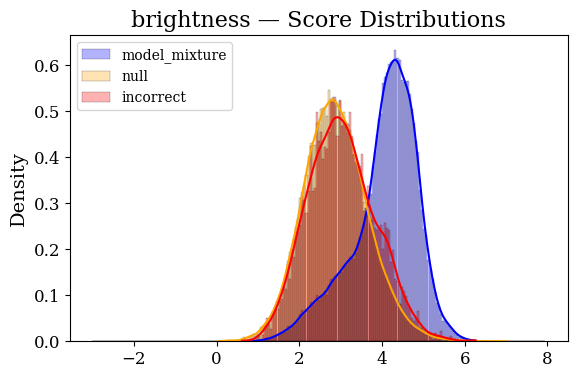

  accuracy : 0.8909
  error/pi0: 0.1091


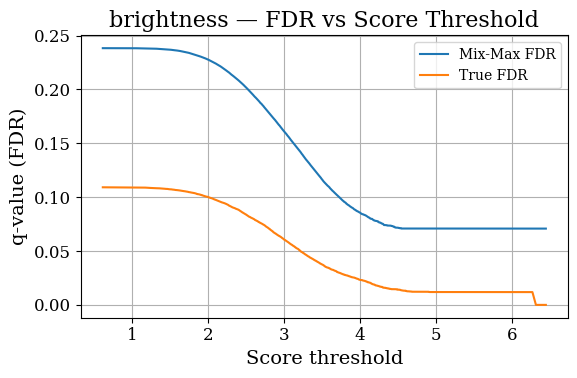

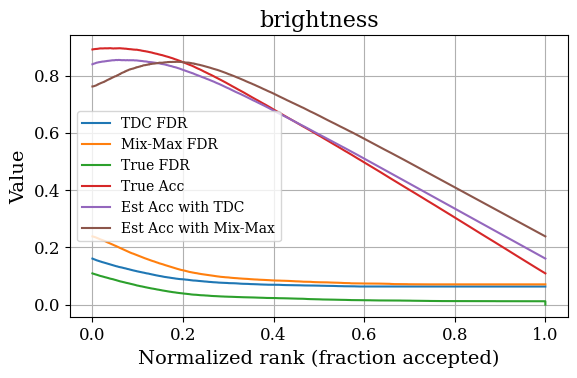


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.8909      0.8955
  TDC  (est | err)             0.8392  +0.0517  0.8544  +0.0410
  Mix-Max (est | err)          0.7617  +0.1291  0.8479  +0.0475

────────────────────────────────────────────────────────────
  CORRUPTION: contrast
────────────────────────────────────────────────────────────


  ATC: 0.820 (error: 0.012)
────────────────────────────────────────────────────────────
  ATC-NE: 0.807 (error: 0.000)
────────────────────────────────────────────────────────────
  AC: 0.880 (error: 0.073)
────────────────────────────────────────────────────────────
  DOC: 0.861 (error: 0.054)
────────────────────────────────────────────────────────────
  COT: 0.821 (error: 0.013)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


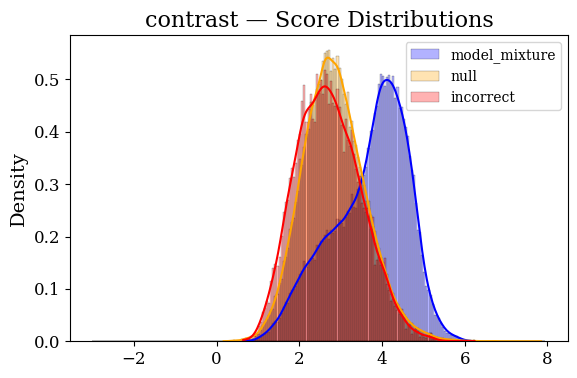

  accuracy : 0.8077
  error/pi0: 0.1923


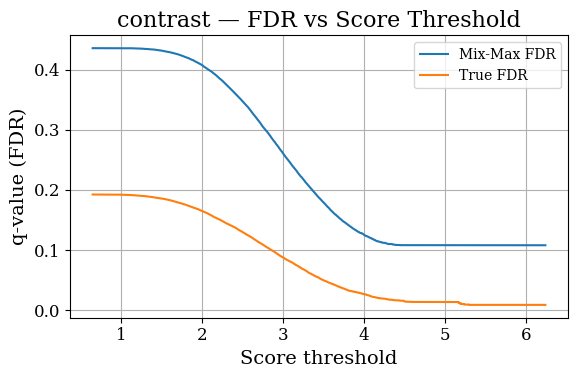

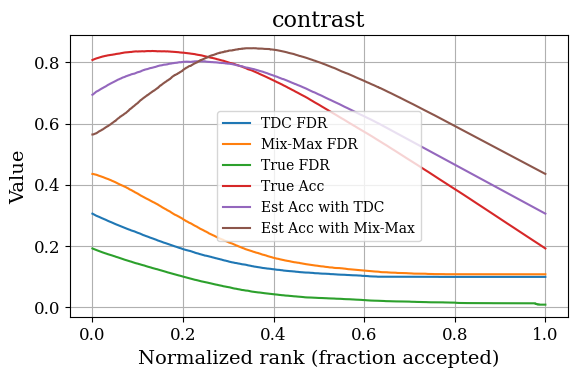


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.8077      0.8372
  TDC  (est | err)             0.6941  +0.1136  0.8037  +0.0335
  Mix-Max (est | err)          0.5644  +0.2433  0.8464  +0.0091

────────────────────────────────────────────────────────────
  CORRUPTION: elastic_transform
────────────────────────────────────────────────────────────


  ATC: 0.792 (error: 0.024)
────────────────────────────────────────────────────────────
  ATC-NE: 0.782 (error: 0.014)
────────────────────────────────────────────────────────────
  AC: 0.865 (error: 0.097)
────────────────────────────────────────────────────────────
  DOC: 0.846 (error: 0.078)
────────────────────────────────────────────────────────────
  COT: 0.793 (error: 0.025)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


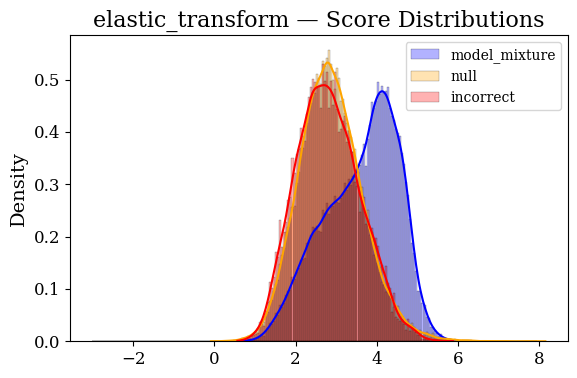

  accuracy : 0.7680
  error/pi0: 0.2320


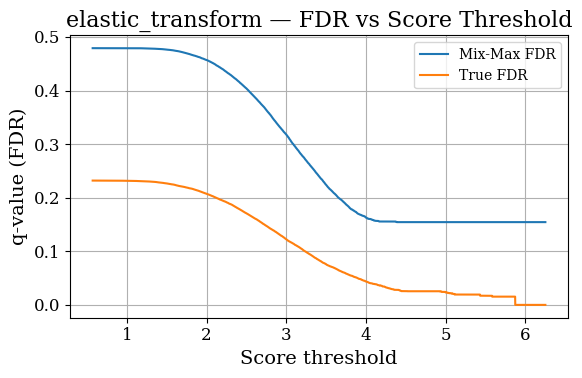

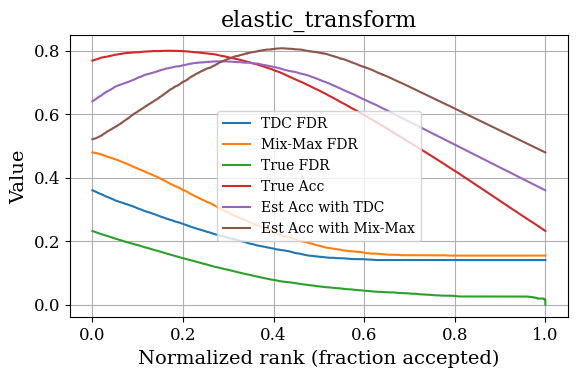


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.7680      0.7994
  TDC  (est | err)             0.6401  +0.1279  0.7663  +0.0332
  Mix-Max (est | err)          0.5209  +0.2471  0.8074  +0.0080

────────────────────────────────────────────────────────────
  CORRUPTION: pixelate
────────────────────────────────────────────────────────────


  ATC: 0.710 (error: 0.106)
────────────────────────────────────────────────────────────
  ATC-NE: 0.691 (error: 0.088)
────────────────────────────────────────────────────────────
  AC: 0.820 (error: 0.217)
────────────────────────────────────────────────────────────
  DOC: 0.801 (error: 0.198)
────────────────────────────────────────────────────────────
  COT: 0.642 (error: 0.039)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


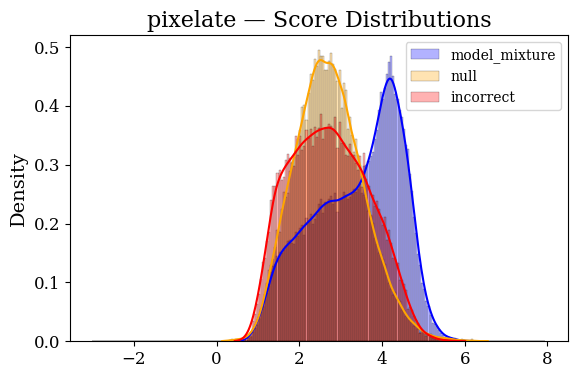

  accuracy : 0.6036
  error/pi0: 0.3964


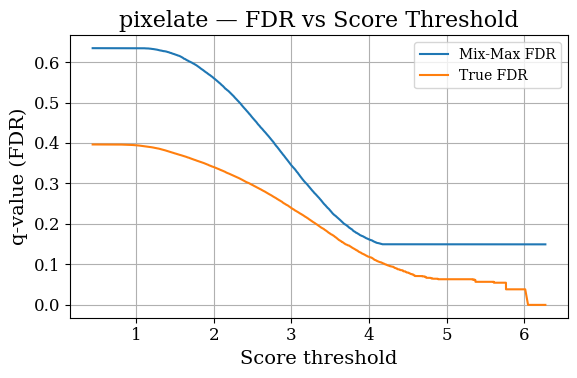

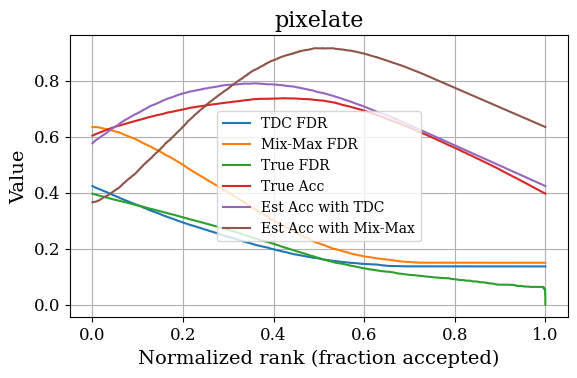


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6036      0.7373
  TDC  (est | err)             0.5764  +0.0272  0.7904  +0.0531
  Mix-Max (est | err)          0.3657  +0.2380  0.9160  +0.1787

────────────────────────────────────────────────────────────
  CORRUPTION: jpeg_compression
────────────────────────────────────────────────────────────


  ATC: 0.772 (error: 0.014)
────────────────────────────────────────────────────────────
  ATC-NE: 0.756 (error: 0.001)
────────────────────────────────────────────────────────────
  AC: 0.854 (error: 0.097)
────────────────────────────────────────────────────────────
  DOC: 0.835 (error: 0.078)
────────────────────────────────────────────────────────────
  COT: 0.804 (error: 0.046)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


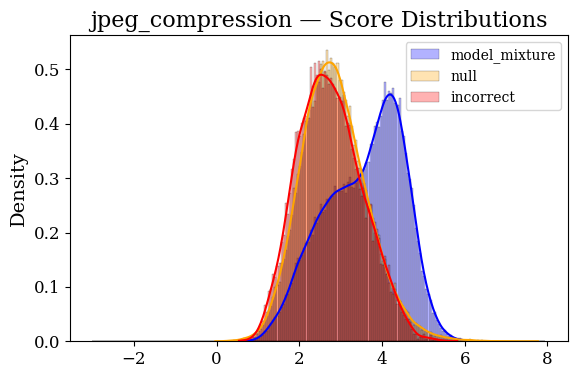

  accuracy : 0.7575
  error/pi0: 0.2425


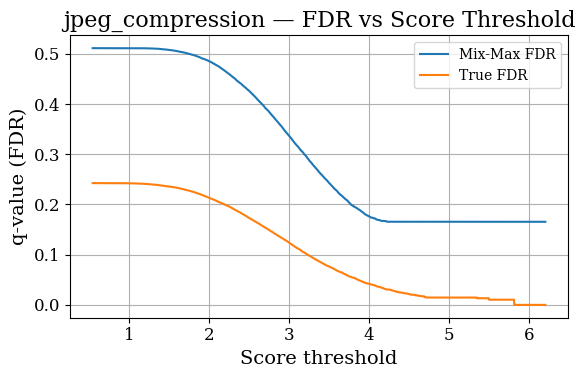

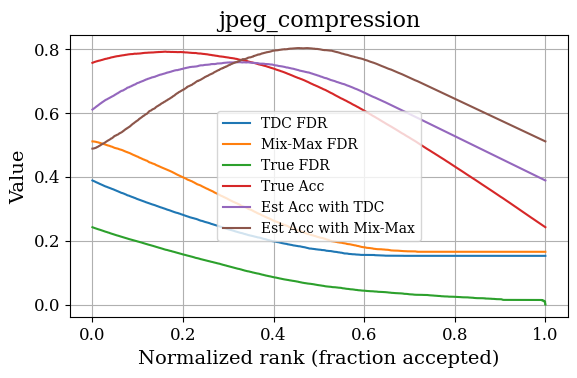


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.7575      0.7926
  TDC  (est | err)             0.6110  +0.1464  0.7596  +0.0330
  Mix-Max (est | err)          0.4887  +0.2688  0.8038  +0.0112

────────────────────────────────────────────────────────────
  CORRUPTION: speckle_noise
────────────────────────────────────────────────────────────


  ATC: 0.653 (error: 0.063)
────────────────────────────────────────────────────────────
  ATC-NE: 0.631 (error: 0.042)
────────────────────────────────────────────────────────────
  AC: 0.791 (error: 0.202)
────────────────────────────────────────────────────────────
  DOC: 0.772 (error: 0.183)
────────────────────────────────────────────────────────────
  COT: 0.646 (error: 0.057)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


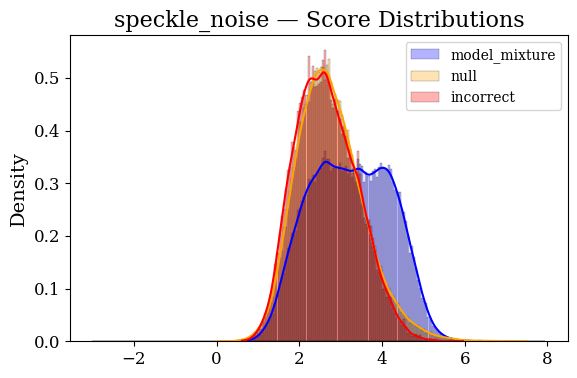

  accuracy : 0.5892
  error/pi0: 0.4108


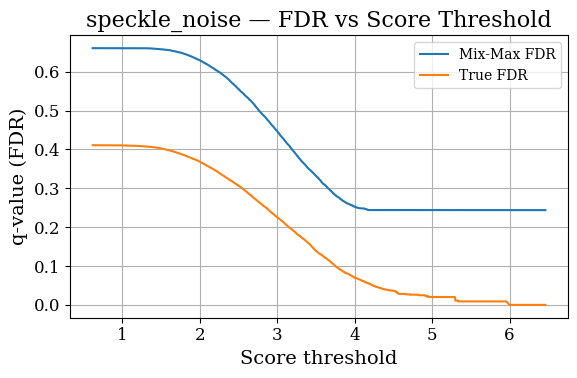

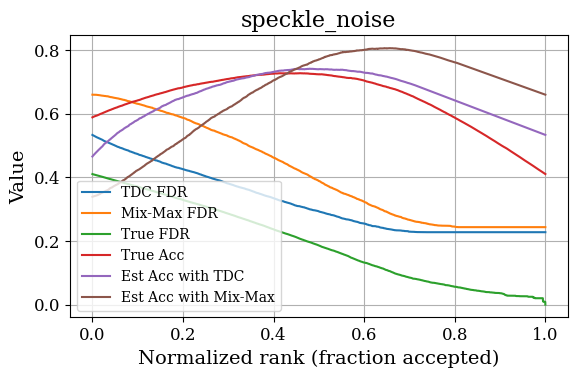


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.5892      0.7281
  TDC  (est | err)             0.4660  +0.1232  0.7422  +0.0141
  Mix-Max (est | err)          0.3395  +0.2497  0.8069  +0.0787

────────────────────────────────────────────────────────────
  CORRUPTION: gaussian_blur
────────────────────────────────────────────────────────────


  ATC: 0.686 (error: 0.064)
────────────────────────────────────────────────────────────
  ATC-NE: 0.666 (error: 0.044)
────────────────────────────────────────────────────────────
  AC: 0.811 (error: 0.189)
────────────────────────────────────────────────────────────
  DOC: 0.792 (error: 0.170)
────────────────────────────────────────────────────────────
  COT: 0.695 (error: 0.073)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


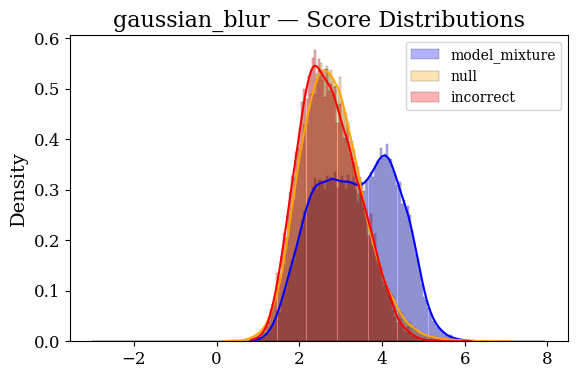

  accuracy : 0.6220
  error/pi0: 0.3780


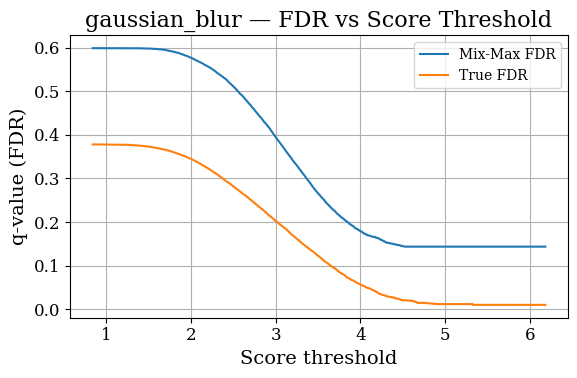

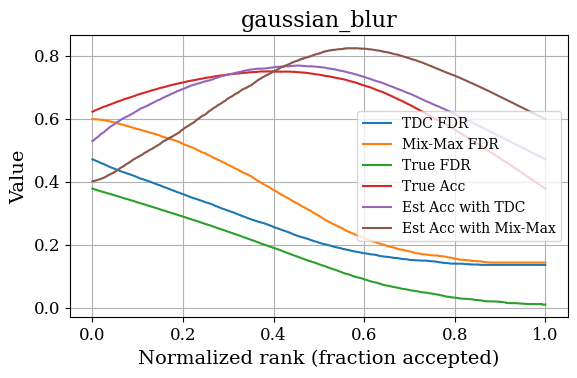


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6220      0.7498
  TDC  (est | err)             0.5290  +0.0930  0.7685  +0.0187
  Mix-Max (est | err)          0.4015  +0.2205  0.8234  +0.0736

────────────────────────────────────────────────────────────
  CORRUPTION: spatter
────────────────────────────────────────────────────────────


  ATC: 0.830 (error: 0.032)
────────────────────────────────────────────────────────────
  ATC-NE: 0.820 (error: 0.022)
────────────────────────────────────────────────────────────
  AC: 0.887 (error: 0.089)
────────────────────────────────────────────────────────────
  DOC: 0.868 (error: 0.070)
────────────────────────────────────────────────────────────
  COT: 0.805 (error: 0.007)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


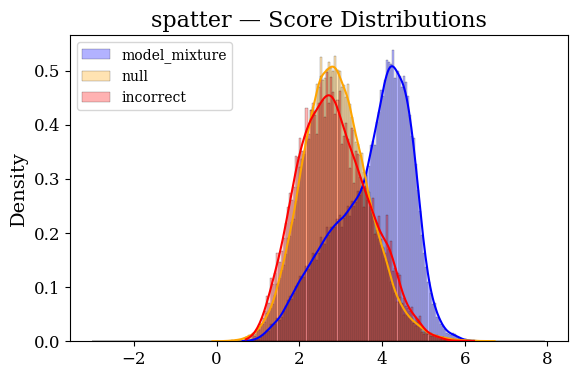

  accuracy : 0.7980
  error/pi0: 0.2020


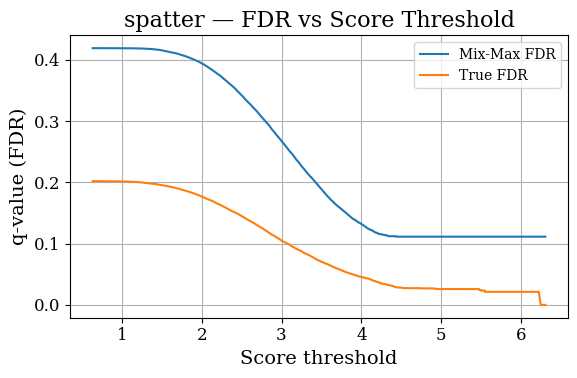

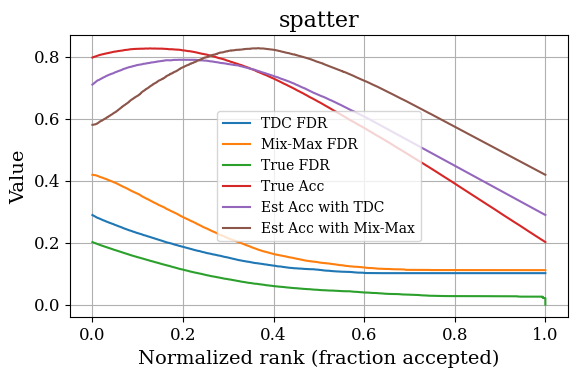


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.7980      0.8276
  TDC  (est | err)             0.7105  +0.0874  0.7911  +0.0364
  Mix-Max (est | err)          0.5807  +0.2172  0.8283  +0.0007

────────────────────────────────────────────────────────────
  CORRUPTION: saturate
────────────────────────────────────────────────────────────


  ATC: 0.893 (error: 0.014)
────────────────────────────────────────────────────────────
  ATC-NE: 0.894 (error: 0.014)
────────────────────────────────────────────────────────────
  AC: 0.923 (error: 0.044)
────────────────────────────────────────────────────────────
  DOC: 0.904 (error: 0.025)
────────────────────────────────────────────────────────────
  COT: 0.881 (error: 0.002)
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────


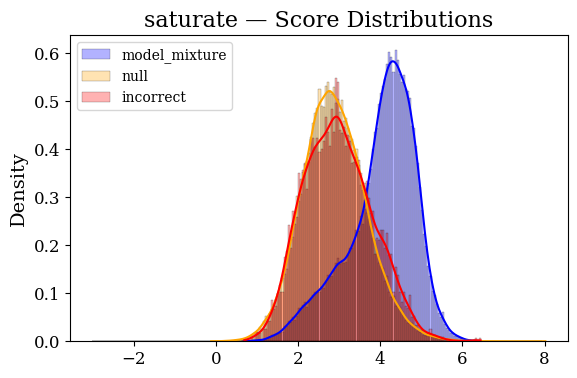

  accuracy : 0.8792
  error/pi0: 0.1208


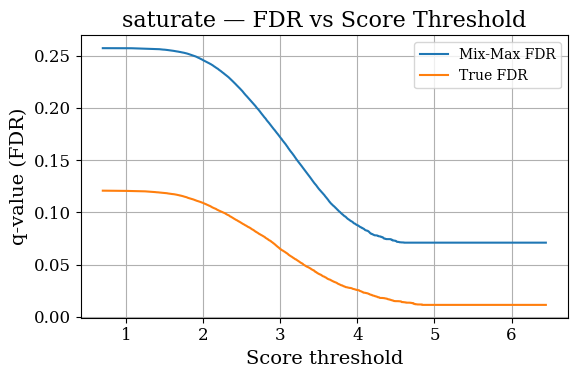

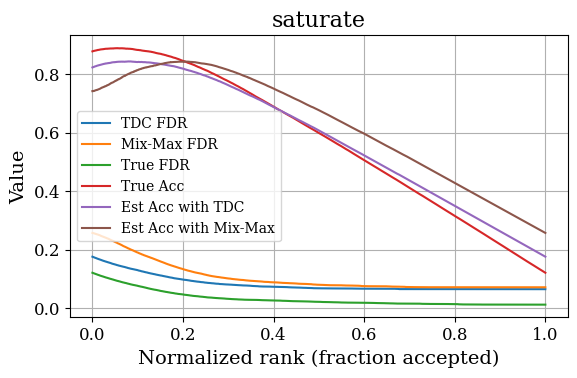


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.8792      0.8902
  TDC  (est | err)             0.8242  +0.0550  0.8449  +0.0453
  Mix-Max (est | err)          0.7428  +0.1364  0.8444  +0.0458

AGGREGATE SUMMARY  (mean ± std across corruptions)

  Metric                                  Mean        Std     Type
  ────────────────────────────────────────────────────────────
  True ACC_ST                           0.6783     0.1429         
  True ACC_TA                           0.7820     0.0533         
  ENPE    est ACC_ST                    0.5497     0.2038       ST
  ENPE    est ACC_TA                    0.8001     0.0769       TA
  ENPE-TA est ACC_ST                    0.4396     0.1845       ST
  ENPE-TA est ACC_TA                    0.8414     0.0584       TA
  ────────────────────────────────────────────────────────────
  ATC est ACC_ST                        0.7261     0.1189   

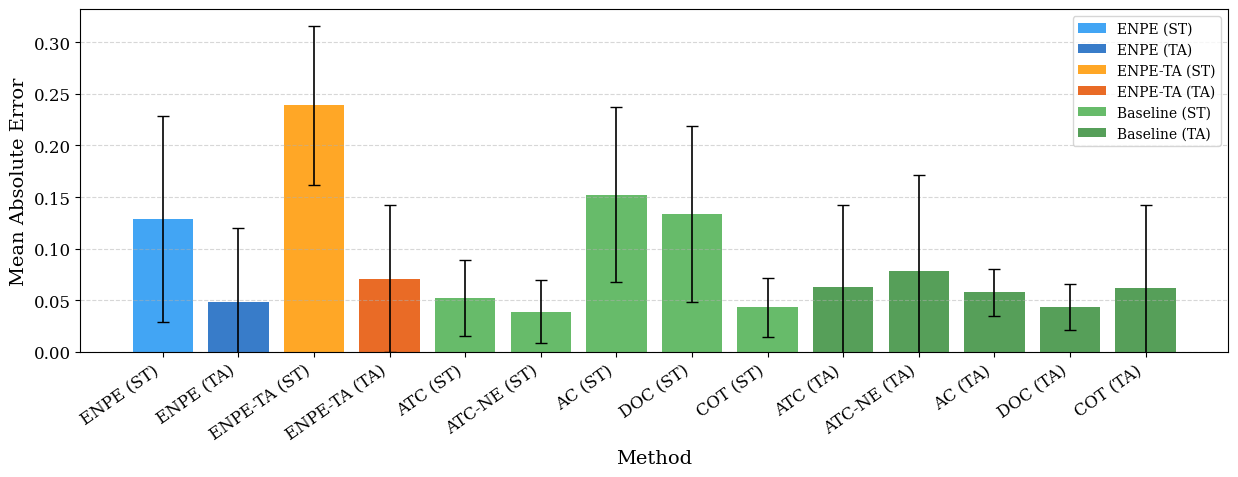

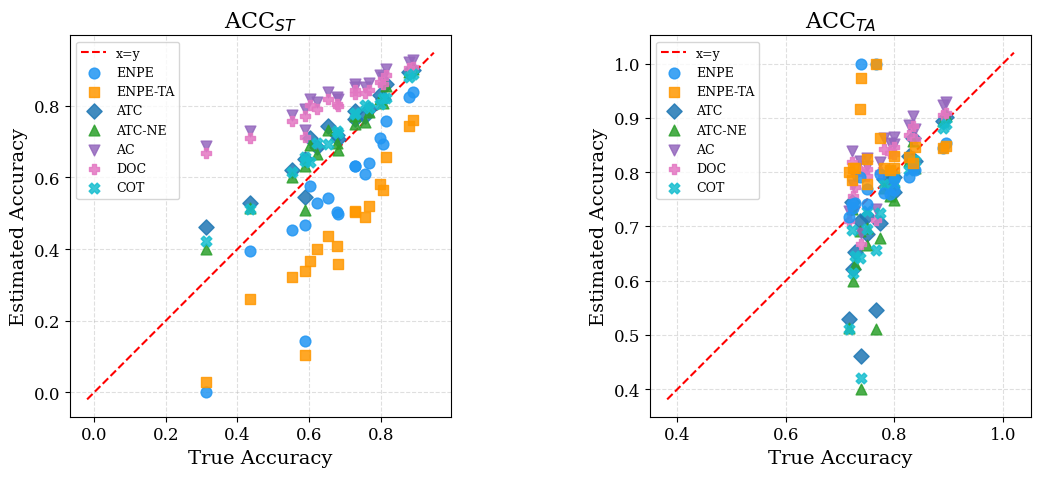

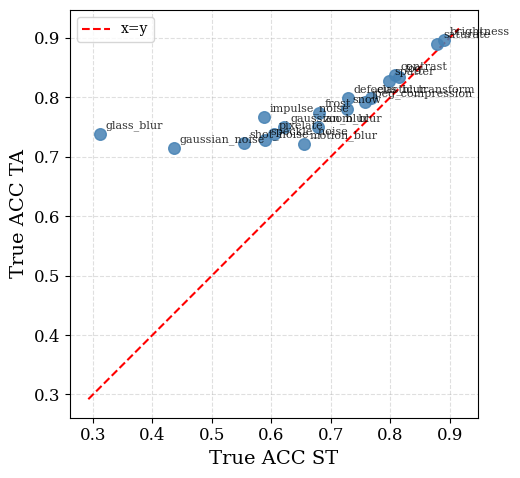

In [8]:
all_results = []

for corruption, dataset in test_corrupted_datasets.items():
    print(f"\n{'─'*60}")
    print(f"  CORRUPTION: {corruption}")
    print(f"{'─'*60}")

    # ── Score dataset БЕЗ decoys (Flow генерирует их сам) ────────────────
    score_ds = create_score_dataset_no_decoys(
        dataset, cifar_model, DEVICE)

    ms, ds_flow, ls = score_shift_flow.generate_decoys(
        score_ds, device=DEVICE)

    target_logits = torch.tensor(ms).to(DEVICE)
    target_labels = torch.tensor(ls).to(DEVICE)

    true_acc = (target_logits.argmax(1) == target_labels).float().mean().item()

    temp           = calibration_temp(source_logits, source_labels)
    scaled_source  = source_logits / temp
    scaled_target  = target_logits / temp

    # ── Baseline methods ──────────────────────────────────────────────────
    baseline_estimates = {}
    baseline_errors    = {}

    for method_name, method_func in BASELINE_METHODS.items():
        estimate = method_func(scaled_source, source_labels, scaled_target)
        error    = abs(estimate - true_acc)
        baseline_estimates[method_name] = float(estimate)
        baseline_errors[method_name]    = float(error)
        print(f"  {method_name}: {estimate:.3f} (error: {error:.3f})")
        print(f"{'─'*60}")

    print(f"{'─'*60}")
    true_acc_full = float((ms.argmax(axis=1) == ls).mean())
    bin_width  = 0.05
    bins       = np.arange(-3, 8, bin_width)
    stat       = 'density'
    plot_alpha = 0.3

    true_labels  = ls
    n_samples    = len(true_labels)

    pred_scores  = np.max(ms, axis=1)
    pred_label   = np.argmax(ms, axis=1)
    decoy_scores = np.max(ds_flow, axis=1)

    # ── Figure 1: Score distributions ────────────────────────────────────
    plt.figure(figsize=(6, 4))
    sns.histplot(pred_scores,
                 bins=bins, stat=stat, color='blue',   kde=True,
                 fill=True, alpha=plot_alpha, label='model_mixture')
    sns.histplot(decoy_scores,
                 bins=bins, stat=stat, color='orange', kde=True,
                 fill=True, alpha=plot_alpha, label='null')
    sns.histplot(pred_scores[true_labels != pred_label],
                 bins=bins, stat=stat, color='red',    kde=True,
                 fill=True, alpha=plot_alpha, label='incorrect')
    plt.title(f'{corruption} — Score Distributions')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/distributions/{corruption}_scores.png', dpi=150)
    plt.savefig(f'figures/distributions/{corruption}_scores.pdf')
    plt.show()

    # ── True FDR (ground truth) ───────────────────────────────────────────
    sort_idx            = np.argsort(pred_scores)
    pred_scores_sorted  = pred_scores[sort_idx]
    label_sorted        = true_labels[sort_idx]
    pred_label_sorted   = pred_label[sort_idx]
    correct_pred        = (label_sorted == pred_label_sorted).astype(int)

    print(f"  accuracy : {correct_pred.sum() / n_samples:.4f}")
    print(f"  error/pi0: {1 - correct_pred.sum() / n_samples:.4f}")

    FD        = 1 - correct_pred
    FD_CF     = np.cumsum(FD[::-1])[::-1]
    D_CF      = np.arange(0, n_samples)[::-1] + 1
    FDR_true  = FD_CF / D_CF
    FDR_true = np.clip(FDR_true, 0, 1)
    QVAL_true = np.minimum.accumulate(FDR_true)
    QVAL_true = np.clip(QVAL_true, 0, 1)

    # ── Mix-Max FDR ───────────────────────────────────────────────────────
    n   = n_samples
    pi0 = 0.0

    unique_z_vals, counts_z = np.unique(decoy_scores, return_counts=True)
    n_unique_z    = len(unique_z_vals)
    sorted_decoys = np.sort(decoy_scores)

    counts_w_leq_z = np.searchsorted(pred_scores_sorted, unique_z_vals, side='left')
    counts_z_leq_z = np.searchsorted(sorted_decoys,      unique_z_vals, side='left')

    P_W_leq_z = (counts_w_leq_z - pi0 * counts_z_leq_z) / ((1 - pi0) * n)
    P_W_leq_z = np.clip(P_W_leq_z, 0, 1)
    P_Y_leq_z = counts_z_leq_z / n
    P_Y_leq_z = np.clip(P_Y_leq_z, 0, 1)

    R_j = np.divide(P_W_leq_z, P_Y_leq_z,
                    out=np.zeros_like(P_W_leq_z),
                    where=P_Y_leq_z > 0)
    R_j = np.clip(R_j, 0, 1)

    all_thresholds = pred_scores_sorted[::-1]
    fdr_values     = np.zeros(n)

    for i, T in enumerate(all_thresholds):
        D     = i + 1
        F_0   = pi0 * np.sum(decoy_scores > T)
        z_idx = np.searchsorted(unique_z_vals, T, side='left')
        if z_idx >= n_unique_z:
            F_1 = 0.0
        else:
            F_1 = (1 - pi0) * np.sum(R_j[z_idx:] * counts_z[z_idx:])
        fdr_values[i] = (F_0 + F_1) / D if D > 0 else 0

    QVAL_mixmax = np.minimum.accumulate(fdr_values[::-1])
    QVAL_mixmax = np.clip(QVAL_mixmax, 0, 1)

    # ── Figure 2: FDR vs score threshold ─────────────────────────────────
    plt.figure(figsize=(6, 4))
    plt.plot(pred_scores_sorted, QVAL_mixmax, label='Mix-Max FDR')
    plt.plot(pred_scores_sorted, QVAL_true,   label='True FDR')
    plt.xlabel('Score threshold')
    plt.ylabel('q-value (FDR)')
    plt.title(f'{corruption} — FDR vs Score Threshold')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'figures/diagnostics/{corruption}_fdr_vs_score.png', dpi=150)
    plt.savefig(f'figures/diagnostics/{corruption}_fdr_vs_score.pdf')
    plt.show()

    # ── TDC FDR ───────────────────────────────────────────────────────────
    TDC       = (pred_scores > decoy_scores).astype(int)
    TDC_score = np.maximum(pred_scores, decoy_scores)

    tdc_sort_idx = np.argsort(TDC_score)
    TDC_score_s  = TDC_score[tdc_sort_idx]
    TDC_label_s  = TDC[tdc_sort_idx]

    FD_CF    = np.cumsum((1 - TDC_label_s)[::-1])[::-1]
    D_CF     = np.arange(0, n_samples)[::-1] + 1 - FD_CF
    D_CF     = np.maximum(D_CF, 1)
    
    TDC_FDR  = FD_CF / D_CF
    TDC_FDR   = np.clip(TDC_FDR, 0, 1)
    QVAL_TDC = np.minimum.accumulate(TDC_FDR)
    QVAL_TDC  = np.clip(QVAL_TDC, 0, 1)

    # ── Acc estimation ────────────────────────────────────────────────────
    pi0_tdc = QVAL_TDC[0]
    pi0_tdc = np.clip(pi0_tdc,   0.0, 1.0)
    pi0_mm  = QVAL_mixmax[0]
    pi0_mm  = np.clip(pi0_mm, 0.0, 1.0)

    Acc_est    = np.zeros(n)
    Acc_est_MM = np.zeros(n)
    Acc_true   = np.zeros(n)

    for i in range(n):
        TP_true     = correct_pred[i:].sum()
        TN_true     = (1 - correct_pred[:i]).sum()
        Acc_true[i] = (TP_true + TN_true) / n
        

        accepted       = n - i
        FP             = accepted * QVAL_TDC[i]
        TP             = accepted * (1 - QVAL_TDC[i])
        TN             = n * pi0_tdc - FP
        Acc_est[i]     = np.clip((TP + TN) / n, 0.0, 1.0)

        FP             = accepted * QVAL_mixmax[i]
        TP             = accepted * (1 - QVAL_mixmax[i])
        TN             = n * pi0_mm - FP
        Acc_est_MM[i]  = np.clip((TP + TN) / n, 0.0, 1.0)

    # ── Figure 3: Acc & FDR vs normalised rank ────────────────────────────
    normalized_rank = np.arange(n) / n

    plt.figure(figsize=(6, 4))
    plt.plot(normalized_rank, QVAL_TDC,    label='TDC FDR')
    plt.plot(normalized_rank, QVAL_mixmax, label='Mix-Max FDR')
    plt.plot(normalized_rank, QVAL_true,   label='True FDR')
    plt.plot(normalized_rank, Acc_true,    label='True Acc')
    plt.plot(normalized_rank, Acc_est,     label='Est Acc with TDC')
    plt.plot(normalized_rank, Acc_est_MM,  label='Est Acc with Mix-Max')
    plt.xlabel('Normalized rank (fraction accepted)')
    plt.ylabel('Value')
    plt.title(f'{corruption}')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'figures/accuracy/{corruption}_acc_fdr.png', dpi=150)
    plt.savefig(f'figures/accuracy/{corruption}_acc_fdr.pdf')
    plt.show()

    # ── ACC_ST / ACC_TA metrics ───────────────────────────────────────────
    acc_st_true    = Acc_true[0]
    acc_ta_true    = Acc_true.max()

    acc_st_est_tdc = Acc_est[0]
    acc_ta_est_tdc = Acc_est.max()

    acc_st_est_mm  = Acc_est_MM[0]
    acc_ta_est_mm  = Acc_est_MM.max()

    err_st_tdc = abs(acc_st_est_tdc - acc_st_true)
    err_ta_tdc = abs(acc_ta_est_tdc - acc_ta_true)
    err_st_mm  = abs(acc_st_est_mm  - acc_st_true)
    err_ta_mm  = abs(acc_ta_est_mm  - acc_ta_true)

    # Baseline errors vs ACC_TA as well
    baseline_errors_ta = {}
    for method_name in BASELINE_METHODS:
        baseline_errors_ta[method_name] = abs(baseline_estimates[method_name] - acc_ta_true)

    print(f"\n  {'':28} {'ACC_ST':>10}  {'ACC_TA':>10}")
    print(f"  {'─'*52}")
    print(f"  {'True':<28} {acc_st_true:>10.4f}  {acc_ta_true:>10.4f}")
    print(f"  {'TDC  (est | err)':<28} "
          f"{acc_st_est_tdc:>6.4f}  {err_st_tdc:>+.4f}  "
          f"{acc_ta_est_tdc:>6.4f}  {err_ta_tdc:>+.4f}")
    print(f"  {'Mix-Max (est | err)':<28} "
          f"{acc_st_est_mm:>6.4f}  {err_st_mm:>+.4f}  "
          f"{acc_ta_est_mm:>6.4f}  {err_ta_mm:>+.4f}")

    # ── Собираем результаты ───────────────────────────────────────────────
    row = dict(
        corruption      = corruption,
        true_acc        = true_acc,
        acc_st_true     = acc_st_true,
        acc_ta_true     = acc_ta_true,
        acc_st_tdc      = acc_st_est_tdc,
        acc_ta_tdc      = acc_ta_est_tdc,
        err_st_tdc      = err_st_tdc,
        err_ta_tdc      = err_ta_tdc,
        acc_st_mm       = acc_st_est_mm,
        acc_ta_mm       = acc_ta_est_mm,
        err_st_mm       = err_st_mm,
        err_ta_mm       = err_ta_mm,
    )

    for method_name in BASELINE_METHODS:
        row[f'est_{method_name}']     = baseline_estimates[method_name]
        row[f'err_{method_name}']     = baseline_errors[method_name]       # vs ACC_ST
        row[f'err_ta_{method_name}']  = baseline_errors_ta[method_name]    # vs ACC_TA

    all_results.append(row)


# ═══════════════════════════════════════════════════════════════════════════════
# AGGREGATE SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
if all_results:
    df = pd.DataFrame(all_results)

    print("\n" + "="*70)
    print("AGGREGATE SUMMARY  (mean ± std across corruptions)")
    print("="*70)
    print(f"\n  {'Metric':<35} {'Mean':>8}   {'Std':>8}   {'Type':>6}")
    print(f"  {'─'*60}")

    # ── Mean estimated accuracy (not just error) ──────────────────────────
    acc_report = [
        ('acc_st_true',  'True ACC_ST',          ''),
        ('acc_ta_true',  'True ACC_TA',           ''),
        ('acc_st_tdc',   'ENPE    est ACC_ST',    'ST'),
        ('acc_ta_tdc',   'ENPE    est ACC_TA',    'TA'),
        ('acc_st_mm',    'ENPE-TA est ACC_ST',    'ST'),
        ('acc_ta_mm',    'ENPE-TA est ACC_TA',    'TA'),
    ]
    for col, name, kind in acc_report:
        v = df[col].values
        print(f"  {name:<35} {v.mean():>8.4f}   {v.std():>8.4f}   {kind:>6}")

    print(f"  {'─'*60}")

    # Baseline mean estimated accuracy
    for method_name in BASELINE_METHODS:
        col  = f'est_{method_name}'
        name = f'{method_name} est ACC_ST'
        v    = df[col].values
        print(f"  {name:<35} {v.mean():>8.4f}   {v.std():>8.4f}   {'ST':>6}")

    print(f"\n  {'─'*60}")
    print(f"  ERRORS")
    print(f"  {'─'*60}")

    # FDR-based errors
    fdr_report = [
        ('err_st_tdc', '|err| ENPE    vs ACC_ST'),
        ('err_ta_tdc', '|err| ENPE    vs ACC_TA'),
        ('err_st_mm',  '|err| ENPE-TA vs ACC_ST'),
        ('err_ta_mm',  '|err| ENPE-TA vs ACC_TA'),
    ]
    for col, name in fdr_report:
        v = df[col].values
        print(f"  {name:<35} {v.mean():>8.4f}   {v.std():>8.4f}")

    print(f"  {'─'*60}")

    # Baseline errors vs ACC_ST and ACC_TA
    for method_name in BASELINE_METHODS:
        col_st = f'err_{method_name}'
        col_ta = f'err_ta_{method_name}'
        v_st   = df[col_st].values
        v_ta   = df[col_ta].values
        print(f"  {'|err| ' + method_name + ' vs ACC_ST':<35} {v_st.mean():>8.4f}   {v_st.std():>8.4f}")
        print(f"  {'|err| ' + method_name + ' vs ACC_TA':<35} {v_ta.mean():>8.4f}   {v_ta.std():>8.4f}")

    print(f"\n  Full results table:")
    print(df.to_string(index=False, float_format='{:.4f}'.format))

    # =========================================================================
    # FIGURE A: Bar chart — mean absolute error per method
    # =========================================================================
    method_names_bar = (
        ['ENPE (ST)', 'ENPE (TA)', 'ENPE-TA (ST)', 'ENPE-TA (TA)'] +
        [f'{m} (ST)' for m in BASELINE_METHODS] +
        [f'{m} (TA)' for m in BASELINE_METHODS]
    )
    method_cols_bar = (
        ['err_st_tdc', 'err_ta_tdc', 'err_st_mm', 'err_ta_mm'] +
        [f'err_{m}' for m in BASELINE_METHODS] +
        [f'err_ta_{m}' for m in BASELINE_METHODS]
    )

    means_bar = [df[c].mean() for c in method_cols_bar]
    stds_bar  = [df[c].std()  for c in method_cols_bar]

    # Color coding: our methods vs baselines
    n_ours      = 4
    n_baselines = len(BASELINE_METHODS) * 2
    colors_bar  = (
        ['#2196F3', '#1565C0', '#FF9800', '#E65100'] +   # ENPE, ENPE-TA (ST/TA)
        ['#4CAF50'] * len(BASELINE_METHODS) +             # baselines ST
        ['#388E3C'] * len(BASELINE_METHODS)               # baselines TA
    )

    fig, ax = plt.subplots(figsize=(max(8, len(method_names_bar) * 0.9), 5))
    x_pos = np.arange(len(method_names_bar))
    bars  = ax.bar(x_pos, means_bar, yerr=stds_bar,
                   color=colors_bar, capsize=4, alpha=0.85,
                   error_kw=dict(elinewidth=1.2, ecolor='black'))
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_names_bar, rotation=35, ha='right')
    ax.set_ylabel('Mean Absolute Error')
    ax.set_xlabel('Method')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(bottom=0)

    # Legend patches
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2196F3', alpha=0.85, label='ENPE (ST)'),
        Patch(facecolor='#1565C0', alpha=0.85, label='ENPE (TA)'),
        Patch(facecolor='#FF9800', alpha=0.85, label='ENPE-TA (ST)'),
        Patch(facecolor='#E65100', alpha=0.85, label='ENPE-TA (TA)'),
        Patch(facecolor='#4CAF50', alpha=0.85, label='Baseline (ST)'),
        Patch(facecolor='#388E3C', alpha=0.85, label='Baseline (TA)'),
    ]
    ax.legend(handles=legend_elements, fontsize=10)
    plt.tight_layout()
    plt.savefig('figures/summary_bar_mean_error.png', dpi=150)
    plt.savefig('figures/summary_bar_mean_error.pdf')
    plt.show()

    # =========================================================================
    # FIGURE B: Scatter — estimated accuracy vs true accuracy
    #           Combined panel: ACC_ST (left) + ACC_TA (right) on ONE figure
    # =========================================================================
    # Collect all method info for both panels
    # Panel 0 = ACC_ST,  Panel 1 = ACC_TA
    scatter_methods = []

    # Our FDR-based methods
    scatter_methods.append(dict(
        label    = 'ENPE',
        col_est  = 'acc_st_tdc',   # estimated ST
        col_true = 'acc_st_true',
        panel    = 0,
        marker   = 'o', color='#2196F3', zorder=4
    ))
    scatter_methods.append(dict(
        label    = 'ENPE-TA',
        col_est  = 'acc_st_mm',    # estimated ST
        col_true = 'acc_st_true',
        panel    = 0,
        marker   = 's', color='#FF9800', zorder=4
    ))
    scatter_methods.append(dict(
        label    = 'ENPE',
        col_est  = 'acc_ta_tdc',   # estimated TA
        col_true = 'acc_ta_true',
        panel    = 1,
        marker   = 'o', color='#2196F3', zorder=4
    ))
    scatter_methods.append(dict(
        label    = 'ENPE-TA',
        col_est  = 'acc_ta_mm',    # estimated TA
        col_true = 'acc_ta_true',
        panel    = 1,
        marker   = 's', color='#FF9800', zorder=4
    ))

    # Baseline methods
    baseline_colors = plt.cm.tab10(np.linspace(0, 0.9, len(BASELINE_METHODS)))
    baseline_markers = ['D', '^', 'v', 'P', 'X', '*', 'h', '8']
    for idx, method_name in enumerate(BASELINE_METHODS):
        c = baseline_colors[idx]
        m = baseline_markers[idx % len(baseline_markers)]
        # vs ACC_ST  (panel 0)
        scatter_methods.append(dict(
            label    = method_name,
            col_est  = f'est_{method_name}',
            col_true = 'acc_st_true',
            panel    = 0,
            marker   = m, color=c, zorder=3
        ))
        # vs ACC_TA  (panel 1)
        scatter_methods.append(dict(
            label    = method_name,
            col_est  = f'est_{method_name}',
            col_true = 'acc_ta_true',
            panel    = 1,
            marker   = m, color=c, zorder=3
        ))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    panel_titles = ['ACC$_{ST}$', 'ACC$_{TA}$']

    for panel_idx, ax in enumerate(axes):
        all_vals = []
        # diagonal reference
        methods_in_panel = [sm for sm in scatter_methods if sm['panel'] == panel_idx]

        # collect range
        for sm in methods_in_panel:
            all_vals.extend(df[sm['col_true']].values.tolist())
            all_vals.extend(df[sm['col_est']].values.tolist())

        lo = min(all_vals) - 0.02
        hi = max(all_vals) + 0.02
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='x=y', zorder=2)

        # track labels already plotted to avoid duplicate legend entries
        plotted_labels = set()
        for sm in methods_in_panel:
            lbl = sm['label'] if sm['label'] not in plotted_labels else '_nolegend_'
            ax.scatter(
                df[sm['col_true']].values,
                df[sm['col_est']].values,
                label    = lbl,
                marker   = sm['marker'],
                color    = sm['color'],
                s        = 60,
                alpha    = 0.85,
                zorder   = sm['zorder']
            )
            plotted_labels.add(sm['label'])

        ax.set_xlabel('True Accuracy')
        ax.set_ylabel('Estimated Accuracy')
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(linestyle='--', alpha=0.4)
        ax.set_aspect('equal', 'box')

        # subtitle inside panel
        ax.set_title(panel_titles[panel_idx])

    plt.tight_layout()
    plt.savefig('figures/scatter_estimated_vs_true_acc.png', dpi=150)
    plt.savefig('figures/scatter_estimated_vs_true_acc.pdf')
    plt.show()

    # =========================================================================
    # FIGURE C: True ACC_ST vs True ACC_TA  (per corruption)
    # =========================================================================
    fig, ax = plt.subplots(figsize=(6, 5))

    lo = min(df['acc_st_true'].min(), df['acc_ta_true'].min()) - 0.02
    hi = max(df['acc_st_true'].max(), df['acc_ta_true'].max()) + 0.02

    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='x=y')
    ax.scatter(
        df['acc_st_true'].values,
        df['acc_ta_true'].values,
        color='steelblue', s=70, alpha=0.85, zorder=3
    )

    # Annotate each point with corruption name
    for _, row in df.iterrows():
        ax.annotate(
            row['corruption'],
            xy     = (row['acc_st_true'], row['acc_ta_true']),
            xytext = (4, 4),
            textcoords = 'offset points',
            fontsize   = 8,
            alpha      = 0.8
        )

    ax.set_xlabel('True ACC ST')
    ax.set_ylabel('True ACC TA')
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)
    ax.set_aspect('equal', 'box')
    plt.tight_layout()
    plt.savefig('figures/scatter_true_accst_vs_accta.png', dpi=150)
    plt.savefig('figures/scatter_true_accst_vs_accta.pdf')
    plt.show()